**NP PREDICTOR**

NP Predictor is a Machine Learning tool aimed at predicting in vitro radioenhancement of metallic nanoparticles.

**ALPHA NP AND BETA NP PREDICTOR**

This part of NP Predictor aims as providing predictions of Alpha NP and Beta NP LQM parameters in presence of nanoparticles.

**STEP 1 - INIT AND IMPORT DATA**

In [ ]:
#Necessary installations
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 8.9 MB/s eta 0:00:00


In [ ]:
#Import necessary Python libraries

#Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import seaborn as sns
from IPython.display import Markdown
from importlib import reload
import scipy.stats as stats
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr

#Import SckitLearn tools
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin, clone

#Import models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [ ]:
#Import NP Predictor dataset
data = pd.read_excel("np_predictor_alpha_beta_dataset.xlsx", sheet_name = 0, header=0)

df = pd.DataFrame(data)

In [ ]:
#Define input features and output features
data = data.sample(frac=1., axis=0)

#Input features
x_data = data.drop(['Exp', 'Alpha_np', 'Beta_np'], axis=1)

#Output features - y_data1 is for Alpha_np predictions, y_data2 is for Beta_np predictions
y_data1 = data[['Alpha_np']]
y_data2 = data[['Beta_np']]

In [ ]:
#Split data into Train and Test sets (for both models)
np.random.seed(42)

#Train-test split for Alpha NP model
x_train1, x_test1, y_train1, y_test1, train_exp1, test_exp1 = train_test_split(x_data, y_data1, data['Exp'], test_size = 0.2, random_state=42, stratify = data['Cell_type'])

#Train-test split for Beta NP model
x_train2, x_test2, y_train2, y_test2, train_exp2, test_exp2 = train_test_split(x_data, y_data2, data['Exp'], test_size = 0.2, random_state=42, stratify = data['Cell_type'])

In [ ]:
#Create Excel files containing Train and Test data (for both models)

#For predicting Alpha NP
train_df1 = pd.DataFrame(x_train1)
train_df1['Alpha_np'] = y_train1.values
train_df1['Exp'] = train_exp1.values

test_df1 = pd.DataFrame(x_test1)
test_df1['Alpha_np'] = y_test1.values
test_df1['Exp'] = test_exp1.values

train_df1.to_excel("train_set_1.xlsx", index=False)
test_df1.to_excel("test_set_1.xlsx", index=False)


#For predicting Beta NP
train_df2 = pd.DataFrame(x_train2)
train_df2['Beta_np'] = y_train2.values
train_df2['Exp'] = train_exp2.values

test_df2 = pd.DataFrame(x_test2)
test_df2['Beta_np'] = y_test2.values
test_df2['Exp'] = test_exp2.values

train_df2.to_excel("train_set_2.xlsx", index=False)
test_df2.to_excel("test_set_2.xlsx", index=False)

In [ ]:
#Convert y_train into 1D array
y_train1 = np.ravel(y_train1)
y_train2 = np.ravel(y_train2)

#Convert Pandas series into Numpy arrays
x_train1 = np.array(x_train1)
y_train1 = np.array(y_train1)
x_test1 = np.array(x_test1)
y_test1 = np.array(y_test1)
x_train2 = np.array(x_train2)
y_train2 = np.array(y_train2)
x_test2 = np.array(x_test2)
y_test2 = np.array(y_test2)

**STEP 2 - DATA VISUALIZATION AND ANALYSIS**

In [ ]:
#Display raw data
display(data.describe().style.format("{0:.2f}").set_caption("Raw data"))

,Exp,Np_type,Diam,Concentration,Incubation,Cell_type,Oxygenation,Ray_type,Energy,Let,Alpha_ctrl,Beta_ctrl,Alpha_np,Beta_np
count,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00
mean,226.00,66.53,28.53,3.69,19.93,2.42,1.92,1.82,274877.93,4.87,0.23,0.04,0.35,0.04
std,129.18,19.84,43.28,15.26,20.08,1.23,0.33,1.58,854814.06,16.16,0.24,0.03,0.30,0.05
min,3.00,22.00,1.20,0.00,0.00,0.00,0.00,1.00,6.50,0.00,-0.32,-0.02,-0.11,-0.15
25%,114.50,64.00,3.00,0.10,6.00,2.00,2.00,1.00,67.00,0.00,0.06,0.01,0.13,0.01
50%,226.00,78.00,12.70,0.50,24.00,2.00,2.00,1.00,380.00,0.00,0.15,0.03,0.27,0.03
75%,337.50,79.00,50.00,0.80,24.00,3.00,2.00,2.00,2000.00,0.00,0.36,0.05,0.48,0.05
max,449.00,83.00,496.00,100.00,168.00,5.00,2.00,6.00,3480000.00,110.00,1.54,0.20,1.84,0.39


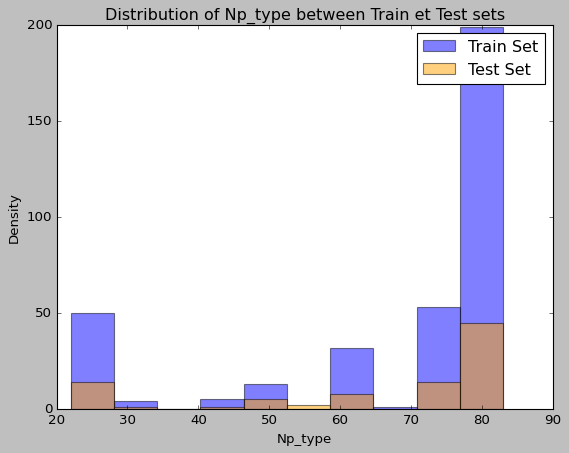

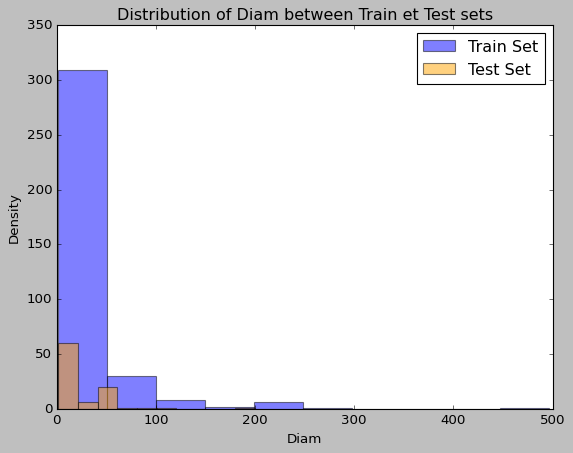

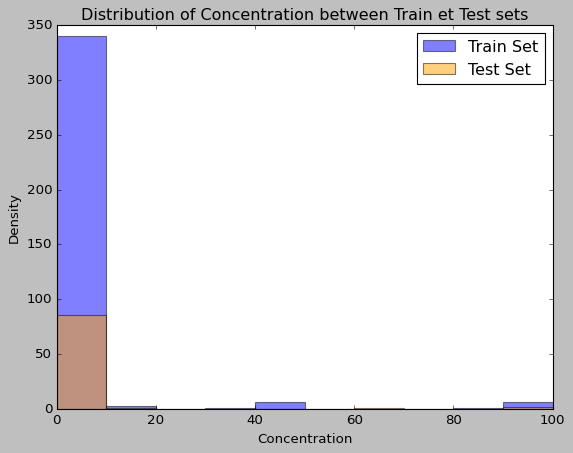

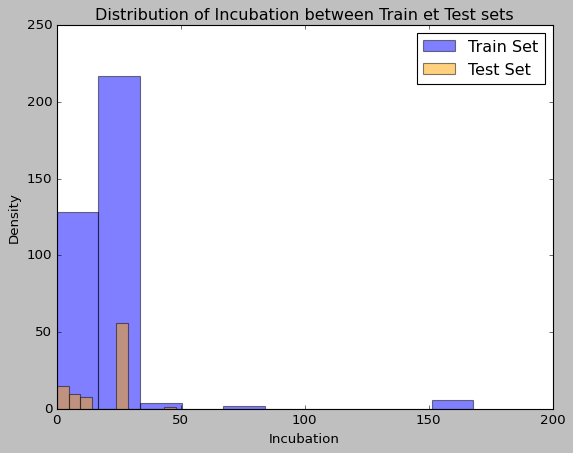

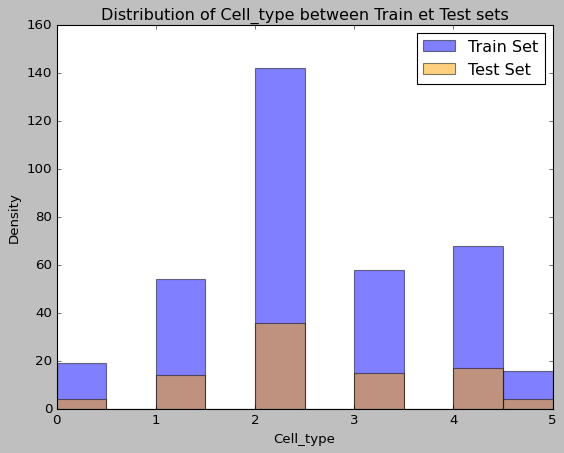

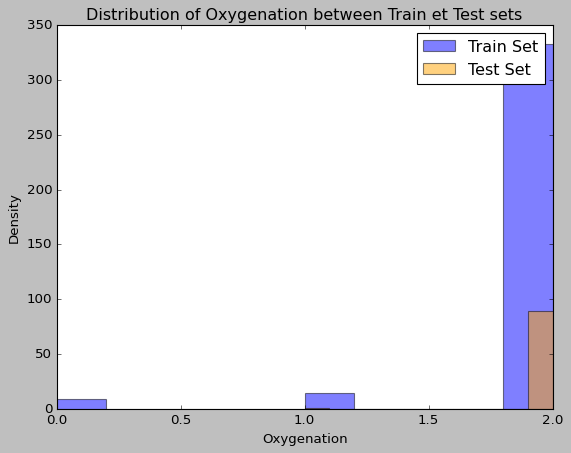

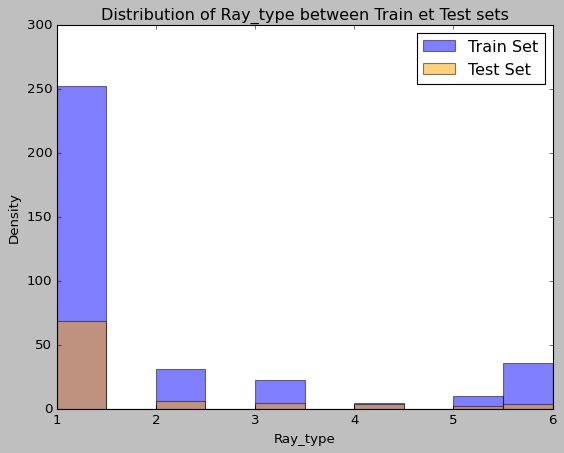

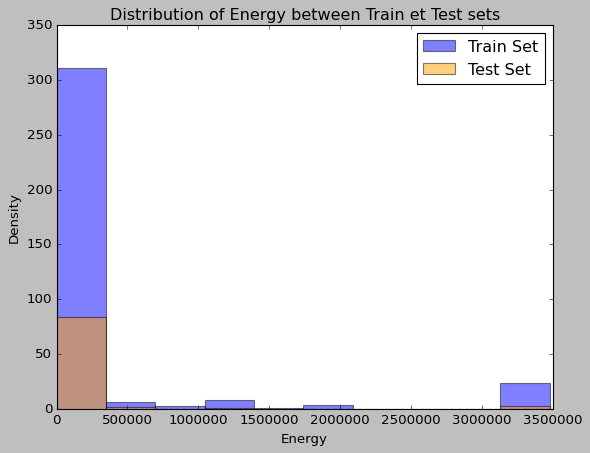

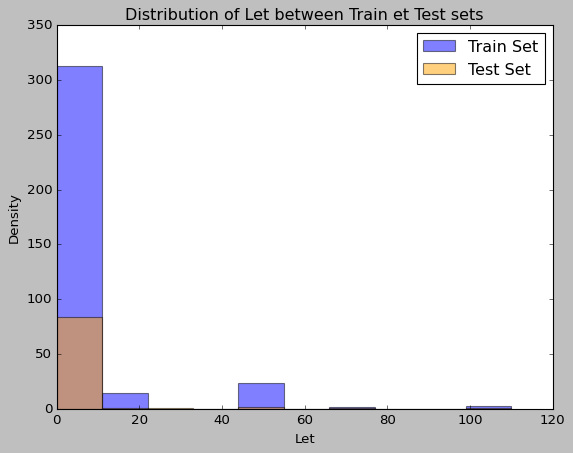

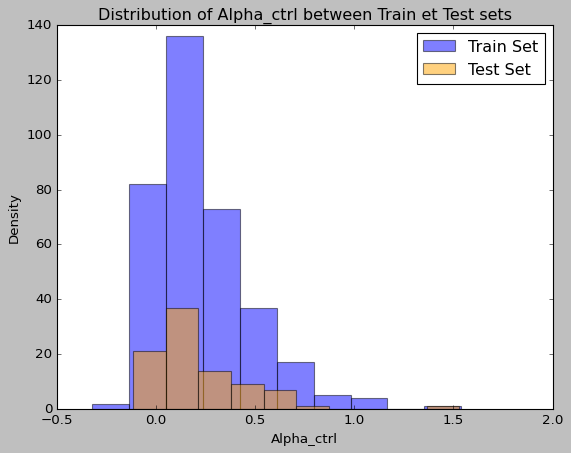

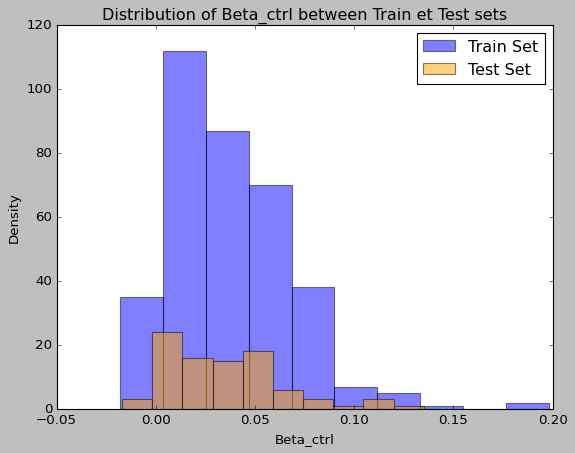

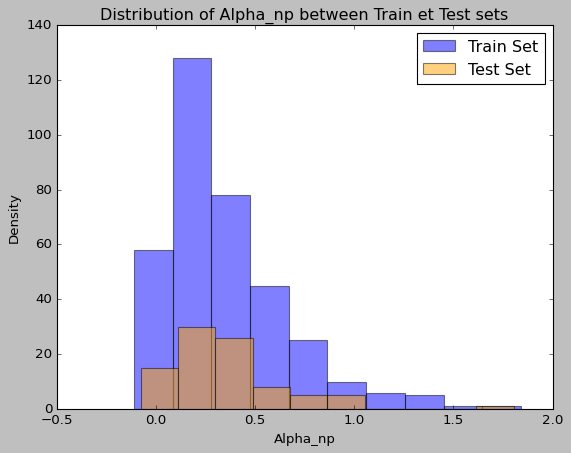

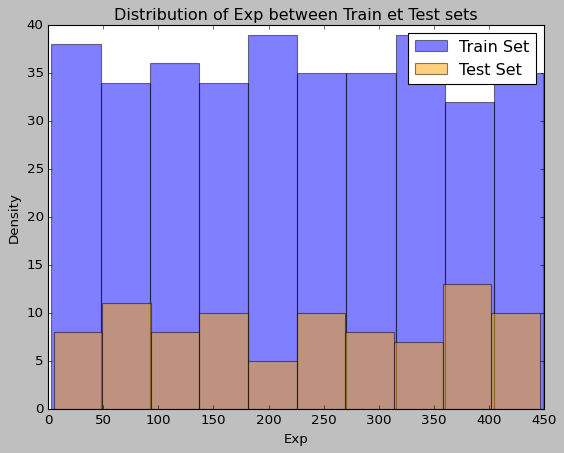

In [ ]:
#Train-Test data repartition histograms
num_bins = 10

for column in train_df1.columns:
  plt.figure(figsize=(8, 6))
  plt.hist(train_df1[column], bins=num_bins, alpha=0.5, label='Train Set', color='blue', density=False)
  plt.hist(test_df1[column], bins=num_bins, alpha=0.5, label='Test Set', color='orange', density=False)
  plt.xlabel(column)
  plt.ylabel('Density')
  plt.title('Distribution of ' + column + ' between Train et Test sets')
  plt.legend()
  plt.show()

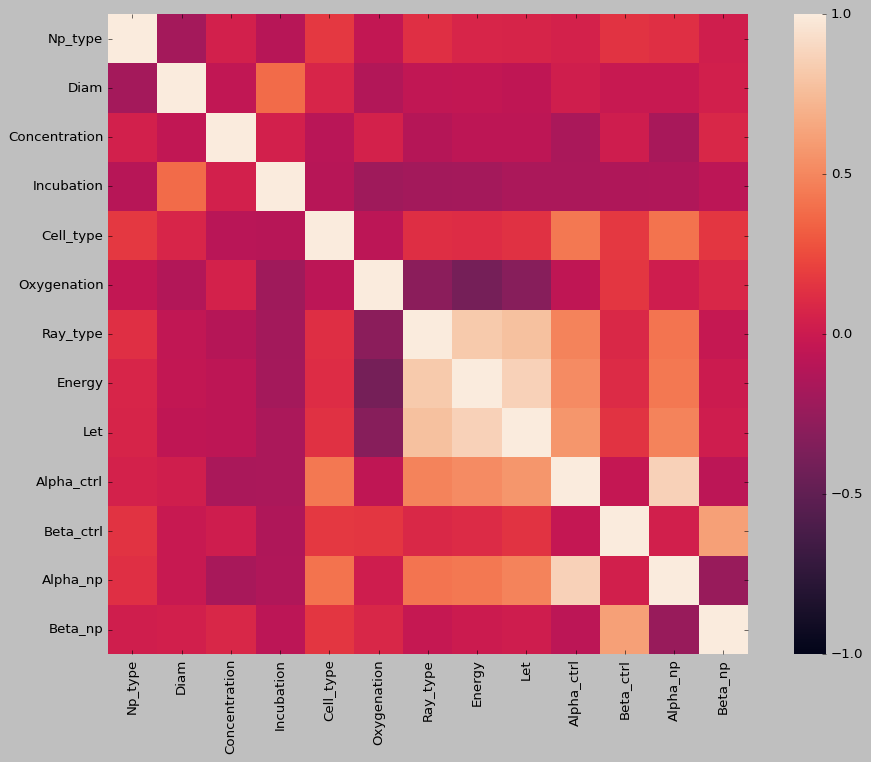

In [ ]:
#Feature correlation heatmap
features = data.drop(['Exp'], axis=1)

corr = features.corr()
f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, vmin=-1., vmax=1., square=True)
plt.show()

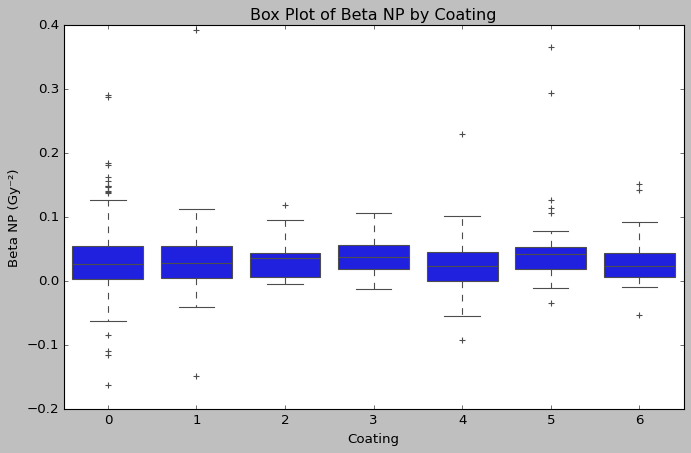

Coating	Num Values	Num Outliers
0		227		16
1		58		2
6		23		3
2		43		1
5		31		6
3		56		0
4		22		2


In [ ]:
#Boxplots for correlation analysis

#Import data to analyze
df_analysis = pd.read_excel("coating_cond_analysis_v3.xlsx")

#Define input and output
input_column = 'Coating'
output_column = 'Beta_np'

#Plot boxplots
plt.figure(figsize=(10,6))
sns.boxplot(x=input_column, y=output_column, data=df_analysis)
plt.title('Box Plot of Beta NP by Coating')
plt.xlabel('Coating')
plt.ylabel('Beta NP (Gy\u207B\u00B2)')
plt.show()

#Number of values and outliers
stats = []


for label in df_analysis[input_column].unique():
  group = df_analysis[df_analysis[input_column] == label][output_column]
  num_values = group.size
  q1 = group.quantile(0.25)
  q3 = group.quantile(0.75)
  iqr = q3 - q1
  outliers = group[(group < q1 - 1.5 * iqr) | (group > q3 + 1.5 * iqr)]
  num_outliers = outliers.size
  stats.append({'Coating': label, 'Num Values': num_values, 'Num Outliers': num_outliers})

print("Coating\tNum Values\tNum Outliers")
for values in stats:
  print(f"{values['Coating']}\t\t{values['Num Values']}\t\t{values['Num Outliers']}")

**STEP 3 - MODEL SELECTION FOR PREDICTING ALPHA NP AND BETA NP**

In this section, we implement two GridSearch CV, involving different ML models, a hyperparameters grid, and a pipeline providing feature standardization.

In [ ]:
#GridSearchCV on multiple models for Alpha NP prediction

#List of ML models
models1 = {
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet(),
    'NeuralNetwork': MLPRegressor(max_iter=500),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': XGBRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'CatBoost': CatBoostRegressor(verbose=0)
}

#Hyperparameters grid for each model
param_grids1 = {
    'Lasso': {
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__max_iter': [100, 500, 1000, 5000]
    },
    'Ridge': {
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        'model__max_iter': [100, 500, 1000, 5000]
    },
    "ElasticNet": {
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0.1, 0.5, 0.8, 0.9],
        'model__max_iter': [100, 500, 1000, 5000]
    },
    'NeuralNetwork': {
        'model__hidden_layer_sizes': [(20,), (50,), (100,), (50, 50), (100,100)],
        'model__activation': ['tanh', 'relu', 'logistic'],
        'model__solver': ['adam'],
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__learning_rate': ['constant', 'invscaling', 'adaptive']
    },
    'SVR': {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'model__gamma': ['scale', 'auto'],
        'model__epsilon': [0.01, 0.1, 0.2]
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10],
        'model__weights': ['uniform', 'distance'],
        'model__algorithm': ['auto'],
        'model__metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'DecisionTree': {
        'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
        'model__max_depth': [None, 10, 20, 30, 50],
        'model__max_features': [None, 'auto', 'sqrt', 'log2'],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'RandomForest': {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30, 50],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__bootstrap': [True, False]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 500],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7, 10],
        'model__subsample': [0.5, 0.7, 1.0],
        'model__colsample_bytree': [0.5, 0.7, 1.0]
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 1.0]
    },
    'CatBoost': {
        'model__iterations': [100, 500, 1000],
        'model__depth': [4, 6, 10],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__l2_leaf_reg': [1, 3, 5, 7]
    }
}

#Define GridSearchCV scorer
def r2_scorer1(estimator, x, y):
  predictions = estimator.predict(x)
  return r2_score(y, predictions)

results1 = []

#GridSearchCV
for model_name1, model1 in models1.items():
  print(f"Training {model_name1}...")
  param_grid1 = param_grids1[model_name1]

  #Define pipeline and standardize features
  pipeline1 = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model1)
  ])

  #Implement and fit GridSearchCV
  grid_search1 = GridSearchCV(pipeline1, param_grid1, cv=5, scoring={'neg_mean_squared_error':'neg_mean_squared_error', 'r2': make_scorer(r2_scorer1)}, refit='neg_mean_squared_error', n_jobs=-1, verbose=1)
  grid_search1.fit(x_train1, y_train1)

  #Collect scores
  best_model1 = grid_search1.best_estimator_
  best_params1 = grid_search1.best_params_
  best_score1 = -grid_search1.best_score_
  y_train_pred1 = best_model1.predict(x_train1)
  train_mse1 = mean_squared_error(y_train1, y_train_pred1)
  train_r2_1 = r2_score(y_train1, y_train_pred1)
  cv_r2_scores1 = cross_val_score(best_model1, x_train1, y_train1, cv=5, scoring=r2_scorer1)
  mean_cv_r2_1 = np.mean(cv_r2_scores1)
  cv_results1 = grid_search1.cv_results_
  best_index1 = grid_search1.best_index_
  mean_val_mse1 = -cv_results1['mean_test_neg_mean_squared_error'][best_index1]
  std_val_mse1 = cv_results1['std_test_neg_mean_squared_error'][best_index1]
  val_r2_1 = cv_results1['mean_test_r2'][best_index1]
  results1.append({
      'Model': model_name1,
      'Best Params': grid_search1.best_params_,
      'Train MSE': train_mse1,
      'Train R2': train_r2_1,
      'Mean CV MSE': mean_val_mse1,
      'Std CV MSE': std_val_mse1,
      'Val R2': mean_cv_r2_1
  })
  print(f"Best model for {model_name1}")
  print(f"Best hyperparameters: {best_params1}")
  print(f"Best mean MSE: {best_score1:.4f}")
  print()

#Export GridSearchCV results to an Excel file
results1_df = pd.DataFrame(results1)
results1_df.to_excel('grid_search_results1.xlsx', index=False)
print("Results saved to grid_search_results1.xlsx")

Training Lasso...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Best model for Lasso
Best hyperparameters: {'model__alpha': 0.01, 'model__max_iter': 100}
Best mean MSE: 0.0201

Training Ridge...
Fitting 5 folds for each of 140 candidates, totalling 700 fits


KeyboardInterrupt: 

In [ ]:
#GridSearchCV on multiple models for Beta NP predictions

#List of ML models
models2 = {
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet(),
    'NeuralNetwork': MLPRegressor(max_iter=500),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': XGBRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'CatBoost': CatBoostRegressor(verbose=0)
}

#Hyperparameters grid for each model
param_grids2 = {
    'Lasso': {
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__max_iter': [100, 500, 1000, 5000]
    },
    'Ridge': {
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        'model__max_iter': [100, 500, 1000, 5000]
    },
    "ElasticNet": {
        'model__alpha': [0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0.1, 0.5, 0.8, 0.9],
        'model__max_iter': [100, 500, 1000, 5000]
    },
    'NeuralNetwork': {
        'model__hidden_layer_sizes': [(20,), (50,), (100,), (50, 50), (100,100)],
        'model__activation': ['tanh', 'relu', 'logistic'],
        'model__solver': ['adam'],
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__learning_rate': ['constant', 'invscaling', 'adaptive']
    },
    'SVR': {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'model__gamma': ['scale', 'auto'],
        'model__epsilon': [0.01, 0.1, 0.2]
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10],
        'model__weights': ['uniform', 'distance'],
        'model__algorithm': ['auto'],
        'model__metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'DecisionTree': {
        'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
        'model__max_depth': [None, 10, 20, 30, 50],
        'model__max_features': [None, 'auto', 'sqrt', 'log2'],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'RandomForest': {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30, 50],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__bootstrap': [True, False]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 500],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7, 10],
        'model__subsample': [0.5, 0.7, 1.0],
        'model__colsample_bytree': [0.5, 0.7, 1.0]
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 1.0]
    },
    'CatBoost': {
        'model__iterations': [100, 500, 1000],
        'model__depth': [4, 6, 10],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__l2_leaf_reg': [1, 3, 5, 7]
    }
}

#Define GridSearchCV scorer
def r2_scorer2(estimator, x, y):
  predictions = estimator.predict(x)
  return r2_score(y, predictions)

results2 = []

#GridSearchCV
for model_name2, model2 in models2.items():
  print(f"Training {model_name2}...")
  param_grid2 = param_grids2[model_name2]

  #Define pipeline and standardize features
  pipeline2 = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model2)
  ])

  #Implement and fit GridSearchCV
  grid_search2 = GridSearchCV(pipeline2, param_grid2, cv=5, scoring={'neg_mean_squared_error':'neg_mean_squared_error', 'r2': make_scorer(r2_scorer2)}, refit='neg_mean_squared_error', n_jobs=-1, verbose=1)
  grid_search2.fit(x_train2, y_train2)

  #Collect scores
  best_model2 = grid_search2.best_estimator_
  best_params2 = grid_search2.best_params_
  best_score2 = -grid_search2.best_score_
  y_train_pred2 = best_model2.predict(x_train2)
  train_mse2 = mean_squared_error(y_train2, y_train_pred2)
  train_r2_2 = r2_score(y_train2, y_train_pred2)
  cv_r2_scores2 = cross_val_score(best_model2, x_train2, y_train2, cv=5, scoring=r2_scorer2)
  mean_cv_r2_2 = np.mean(cv_r2_scores2)
  cv_results2 = grid_search2.cv_results_
  best_index2 = grid_search2.best_index_
  mean_val_mse2 = -cv_results2['mean_test_neg_mean_squared_error'][best_index2]
  std_val_mse2 = cv_results2['std_test_neg_mean_squared_error'][best_index2]
  val_r2_2 = cv_results2['mean_test_r2'][best_index2]
  results2.append({
      'Model': model_name2,
      'Best Params': grid_search2.best_params_,
      'Train MSE': train_mse2,
      'Train R2': train_r2_2,
      'Mean CV MSE': mean_val_mse2,
      'Std CV MSE': std_val_mse2,
      'Val R2': mean_cv_r2_2
  })
  print(f"Best model for {model_name2}")
  print(f"Best hyperparameters: {best_params2}")
  print(f"Best mean MSE: {best_score2:.4f}")
  print()

#Export GridSearchCV results to an Excel file
results2_df = pd.DataFrame(results2)
results2_df.to_excel('grid_search_results2.xlsx', index=False)
print("Results saved to grid_search_results2.xlsx")

Training Lasso...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Best model for Lasso
Best hyperparameters: {'model__alpha': 0.01, 'model__max_iter': 100}
Best mean MSE: 0.0015

Training Ridge...
Fitting 5 folds for each of 140 candidates, totalling 700 fits


KeyboardInterrupt: 

In [ ]:
#Plot metrics distributions for Alpha NP GridSearchCV
results_df1 = pd.read_excel('grid_search_results1.xlsx')

plt.figure(figsize=(10, 6))
plt.hist(results_df1['Mean Validation MSE'], bins=np.linspace(0, 0.1, 100), edgecolor='black', range=(0, 0.1))
plt.title('Distribution of Mean Validation MSE')
plt.xlabel('Mean Validation MSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df1['Std Validation MSE'], bins=np.linspace(0, 0.028, 100), edgecolor='black', range=(0, 0.028))
plt.title('Distribution of Validation MSE Standard Deviation')
plt.xlabel('Validation MSE Standard Deviation')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df1['Validation R2'], bins=np.linspace(0.35, 1, 100), edgecolor='black', range=(0,1))
plt.title('Distribution of Validation R²')
plt.xlabel('Validation R²')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
#Plot metrics distributions for Beta NP GridSearchCV
results_df2 = pd.read_excel('grid_search_results2.xlsx')

plt.figure(figsize=(10, 6))
plt.hist(results_df2['Mean Validation MSE'], bins=np.linspace(0, 2000, 100), edgecolor='black', range=(0,2000))
plt.title('Distribution of Mean Validation MSE')
plt.xlabel('Mean Validation MSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df2['Std Validation MSE'], bins=np.linspace(0, 100, 100), edgecolor='black', range=(0,100))
plt.title('Distribution of Validation MSE Standard Deviation')
plt.xlabel('Validation MSE Standard Deviation')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df2['Validation R2'], bins=np.linspace(0.20, 0.6, 100), edgecolor='black', range=(0,1))
plt.title('Distribution of Validation R²')
plt.xlabel('Validation R²')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**STEP 4 - DEFINE THE BEST ML MODELS**

In this section, we define the best model for Alpha NP and for Beta NP prediction, with the optimal hyperparameters. Two approaches are proposed here: first a definition of a single model for each prediction, then an ensembling method for each prediction.

***Single model approach***

In [ ]:
#Define best single model for Alpha NP prediction - ElasticNet
best_model1 = ElasticNet(
    alpha=0.1,
    l1_ratio=0.8,
    max_iter=200
)

#Fit the model to the train subset
best_model1.fit(x_train1, y_train1)

ElasticNet(alpha=0.01, l1_ratio=0.8, max_iter=100)

In [ ]:
#Define best single model for Beta NP prediction - SupportVectorRegressor
best_model2 = SVR(
    C=1,
    kernel='linear',
    gamma='scale',
    epsilon=0.1
)

#Fit the model to train subset
best_model2.fit(x_train2, y_train2)

SVR(C=1, kernel='linear')

***Ensembling approach***

In [ ]:
#Define ensembling model for Alpha NP prediction

#Model 1a: RandomForest
best_model1a = RandomForestRegressor(
    n_estimators = 500,
    min_samples_split = 2,
    min_samples_leaf = 1,
    max_depth = 30,
    bootstrap = True,
    verbose = 0,
    random_state = 42
)

#Model 1b: CatBoost
best_model1b = CatBoostRegressor(
    iterations = 1000,
    depth = 4,
    l2_leaf_reg = 7,
    learning_rate = 0.2,
    verbose = 0,
    random_state = 42
)

#Model 1c: XGBoost
best_model1c = XGBRegressor(
    n_estimators = 100,
    max_depth = 10,
    learning_rate = 0.1,
    colsample_bytree = 1.0,
    subsample = 0.5,
    random_state = 42
)

#Model 1d: ElasticNet
best_model1d = ElasticNet(
    alpha=0.1,
    l1_ratio=0.8,
    max_iter=200
)

#Fit the model to the train subset
best_model1a.fit(x_train1, y_train1)
best_model1b.fit(x_train1, y_train1)
best_model1c.fit(x_train1, y_train1)
best_model1d.fit(x_train1, y_train1)

ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=200)

In [ ]:
#Define ensembling model for Beta NP prediction

#Hyperparameters setting on Beta NP

#Model 2a: CatBoost
best_model2a = CatBoostRegressor(
    iterations = 500,
    depth = 4,
    l2_leaf_reg = 7,
    learning_rate = 0.1,
    verbose = 0,
    random_state = 42
)

#Model 2b: XGBoost
best_model2b = XGBRegressor(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1,
    colsample_bytree = 0.5,
    subsample = 0.5,
    random_state = 42
)

#Model 2c: RandomForest
best_model2c = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 50,
    min_samples_split = 10,
    min_samples_leaf = 2,
    bootstrap = True,
    verbose = 0,
    random_state = 42
)

#Model 2d: SVR
best_model2d = SVR(
    C=1,
    kernel='linear',
    gamma='scale',
    epsilon=0.1
)


#Fit the model to train subset
best_model2a.fit(x_train2, y_train2)
best_model2b.fit(x_train2, y_train2)
best_model2c.fit(x_train2, y_train2)
best_model2d.fit(x_train2, y_train2)

SVR(C=1, kernel='linear')

**STEP 5 - K-FOLD CROSS-VALIDATION**

In this section, a cross-validation (k=5) is performed in order to assess performance and stability of the model on the train set. In the end, different folds from the train set are regrouped in order to see the predictions on the full train set.

***Single model approach***

Fold 1


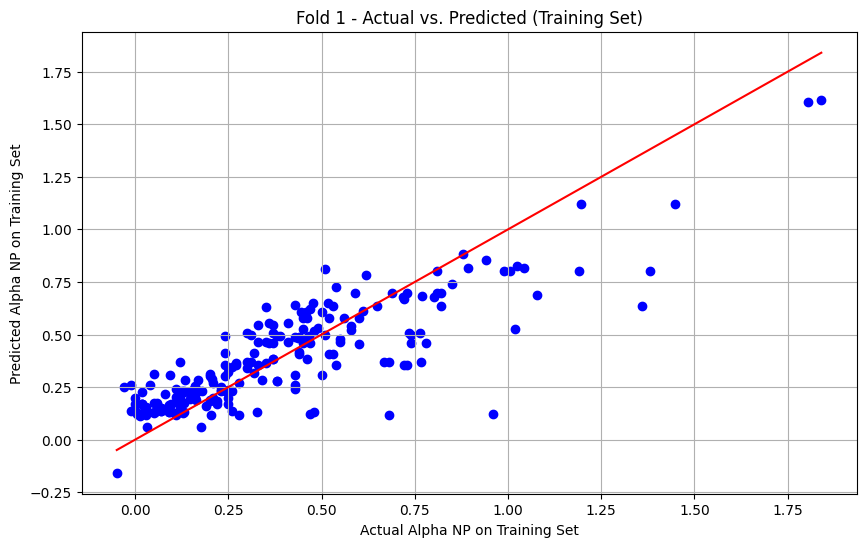

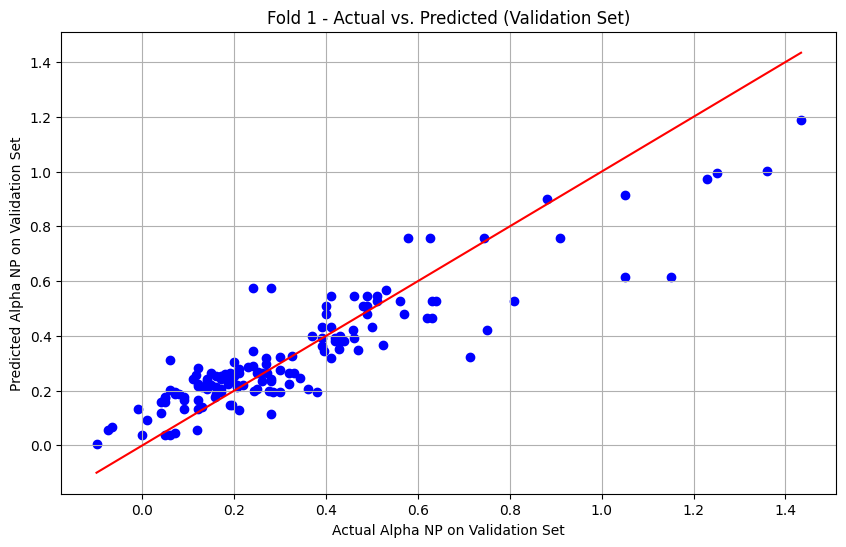

Fold 1 - Train MSE: 0.03007716080580735, Validation MSE: 0.016338753143280302
Fold 2


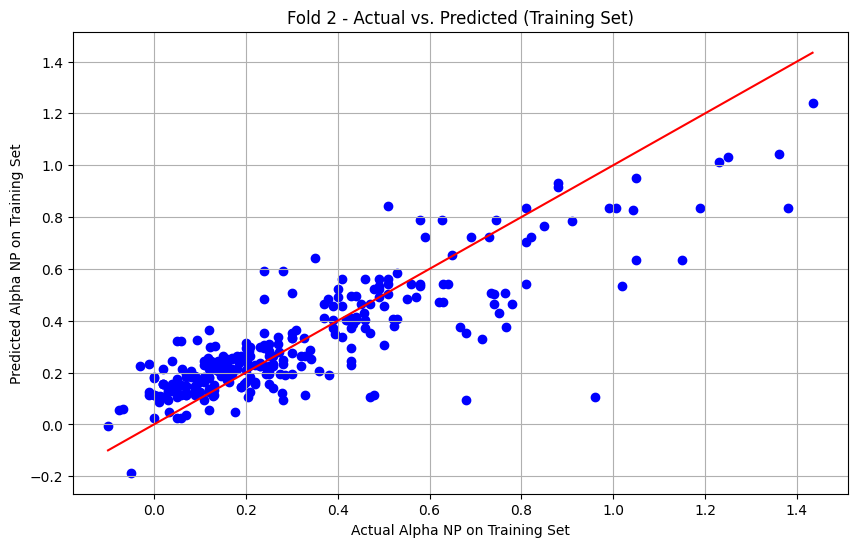

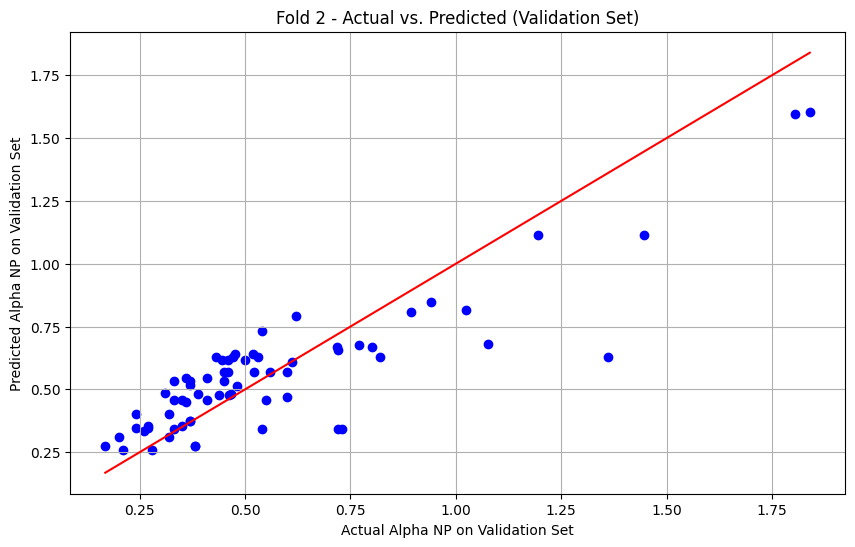

Fold 2 - Train MSE: 0.022883485495041808, Validation MSE: 0.029641843428298655
Fold 3


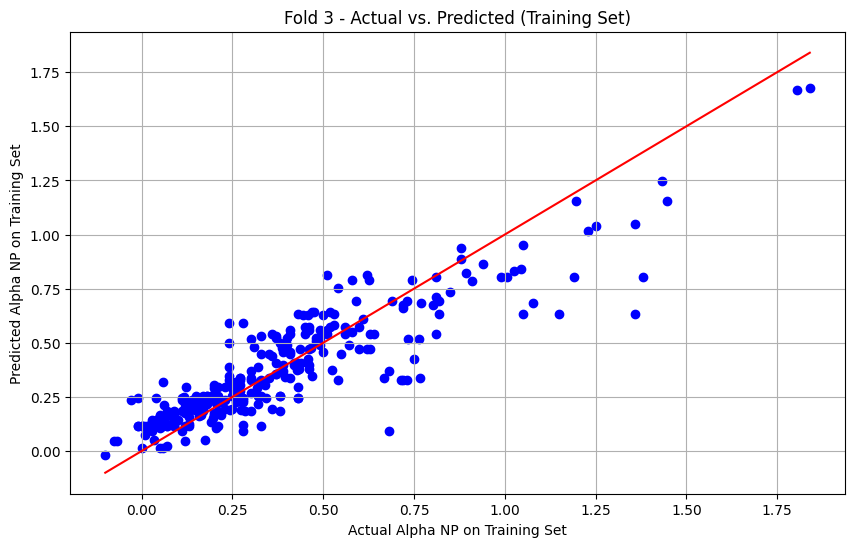

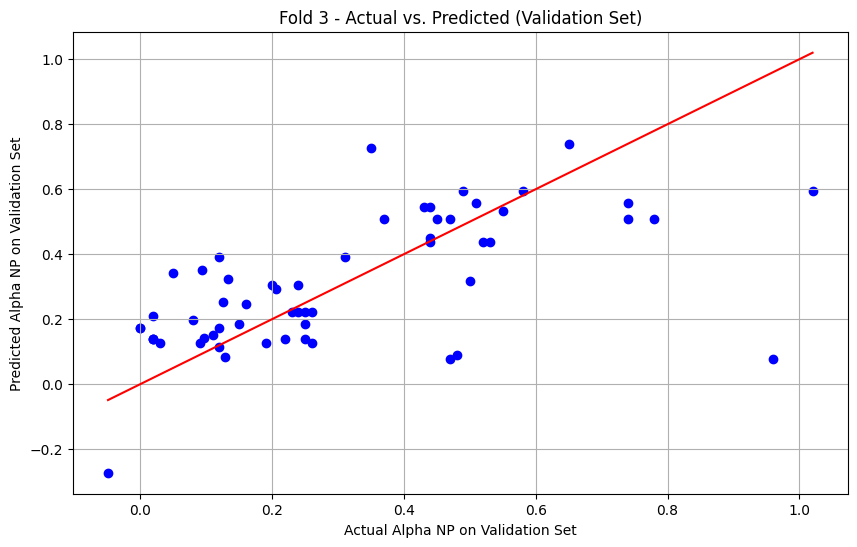

Fold 3 - Train MSE: 0.021794111409733086, Validation MSE: 0.039122025000124655
Fold 4


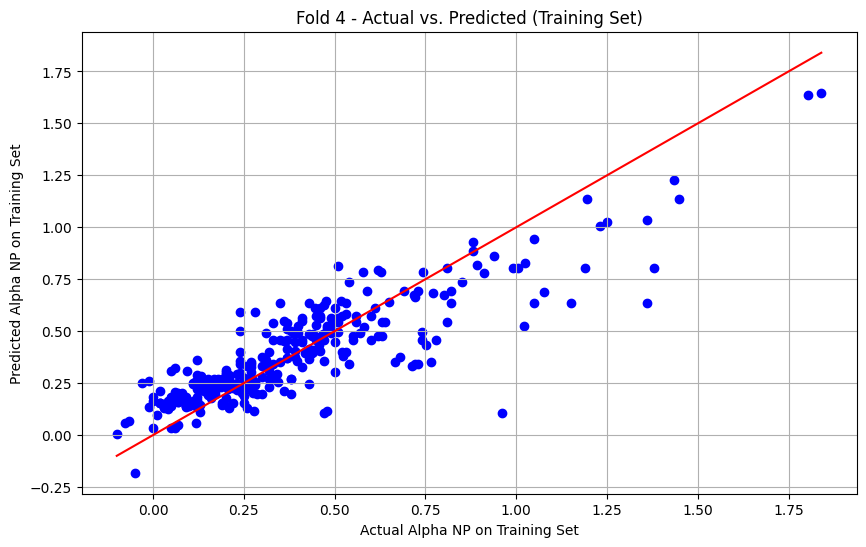

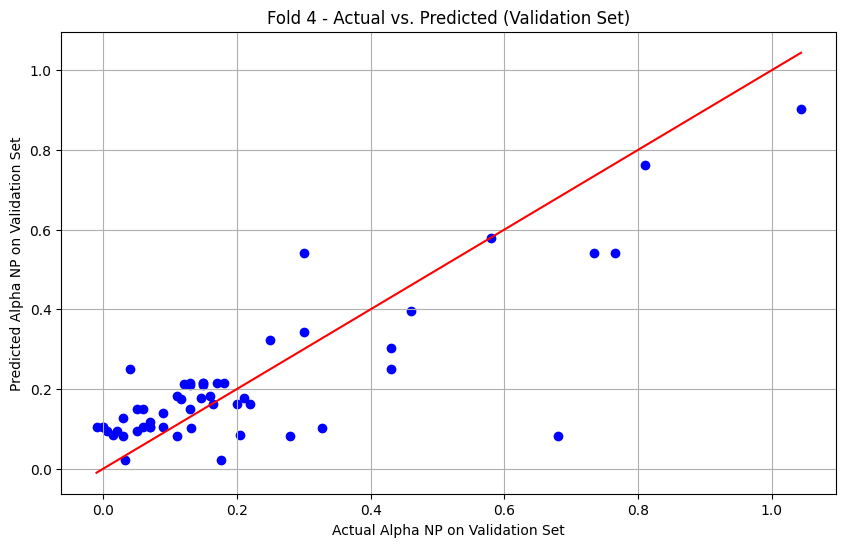

Fold 4 - Train MSE: 0.02557475097645614, Validation MSE: 0.016778625041434334
Fold 5


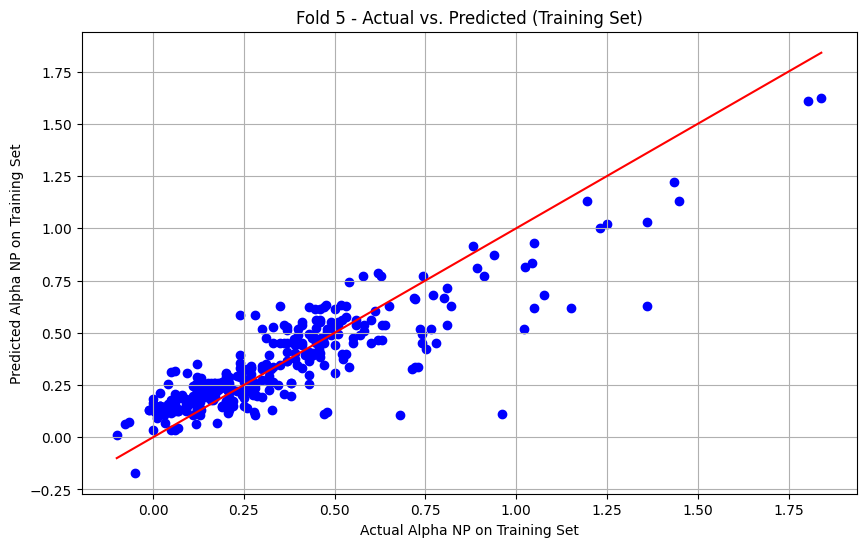

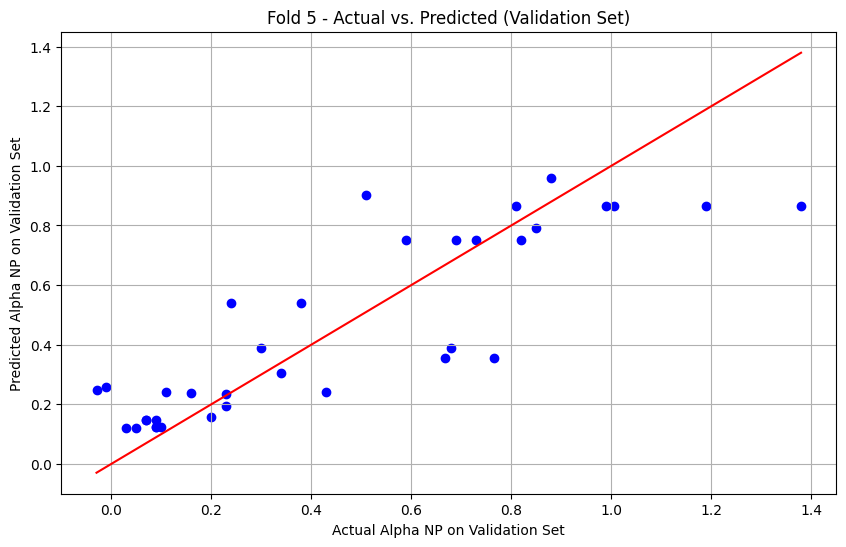

Fold 5 - Train MSE: 0.022712472305823468, Validation MSE: 0.03780916770446867

Metrics for Train Set for Alpha NP Predictor:
Mean MSE: 0.024608396198572368
Standard Deviation of MSE: 0.0030110221221713858

Metrics for Validation Set for Alpha NP Predictor:
Mean MSE: 0.027938082863521323
Standard Deviation of MSE: 0.009843775968153353


In [ ]:
#Cross Validation on single model Alpha NP Predictor

#Convert Numpy arrays into Pandas DataFrames
x_train_df1 = pd.DataFrame(x_train1, columns=x_data.columns)
y_train_df1 = pd.DataFrame(y_train1).reset_index(drop=True)

#Define K-fold CV
group_kfold1 = GroupKFold(n_splits=5)

predicted_values1 = np.zeros_like(y_train1)
actual_values1 = np.zeros_like(y_train1)
train_mse_scores1 = []
val_mse_scores1 = []

#Perform K-fold CV with stratification
for fold_idx, (train_index, val_index) in enumerate(group_kfold1.split(x_train_df1, y_train_df1, groups=x_train_df1['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into Training and Validation folds
  x_train_fold_df1, x_val_fold_df1 = x_train_df1.iloc[train_index], x_train_df1.iloc[val_index]
  y_train_fold_df1, y_val_fold_df1 = y_train_df1.iloc[train_index], y_train_df1.iloc[val_index]
  exp_val1 = train_df1['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold1 = x_train_fold_df1.values
  x_val_fold1 = x_val_fold_df1.values
  y_train_fold1 = y_train_fold_df1.values
  y_val_fold1 = y_val_fold_df1.values

  #Scale data
  scaler_x_train1 = StandardScaler()
  scaler_x_val1 = StandardScaler()

  x_train_fold_scaled1 = scaler_x_train1.fit_transform(x_train_fold1)
  x_val_fold_scaled1 = scaler_x_val1.fit_transform(x_val_fold1)

  scaler_y_train1 = StandardScaler()
  scaler_y_val1 = StandardScaler()

  y_train_fold_scaled1 = scaler_y_train1.fit_transform(y_train_fold1.reshape(-1,1)).flatten()
  y_val_fold_scaled1 = scaler_y_val1.fit_transform(y_val_fold1.reshape(-1,1)).flatten()

  #Fit best model
  best_model1.fit(x_train_fold_scaled1, y_train_fold_scaled1)

  #Make predictions
  y_train_pred_scaled1 = best_model1.predict(x_train_fold_scaled1)
  y_train_pred1 = scaler_y_train1.inverse_transform(y_train_pred_scaled1.reshape(-1,1)).flatten()

  y_val_pred_scaled1 = best_model1.predict(x_val_fold_scaled1)
  y_val_pred1 = scaler_y_val1.inverse_transform(y_val_pred_scaled1.reshape(-1,1)).flatten()

  #Plot predictions on training folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_train_fold1, y_train_pred1, color='blue')
  # plt.xlim(-0.12, 1.4)
  # plt.ylim(-0.12, 1.4)
  plt.plot([min(y_train_fold1), max(y_train_fold1)], [min(y_train_fold1), max(y_train_fold1)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Training Set)")
  plt.xlabel("Actual Alpha NP on Training Set")
  plt.ylabel("Predicted Alpha NP on Training Set")
  plt.grid(True)
  plt.show()

  y_val_pred_scaled1 = best_model1.predict(x_val_fold_scaled1)
  y_val_pred1 = scaler_y_val1.inverse_transform(y_val_pred_scaled1.reshape(-1,1)).flatten()

  #Plot predictions on validation folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_val_fold1, y_val_pred1, color='blue')
  # plt.xlim(-0.12, 1.4)
  # plt.ylim(-0.12, 1.4)
  plt.plot([min(y_val_fold1), max(y_val_fold1)], [min(y_val_fold1), max(y_val_fold1)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Validation Set)")
  plt.xlabel("Actual Alpha NP on Validation Set")
  plt.ylabel("Predicted Alpha NP on Validation Set")
  plt.grid(True)
  plt.show()

  #Collect CV results
  train_mse1 = mean_squared_error(y_train_fold1, y_train_pred1)
  val_mse1 = mean_squared_error(y_val_fold1, y_val_pred1)
  train_mse_scores1.append(train_mse1)
  val_mse_scores1.append(val_mse1)
  print(f"Fold {fold_idx + 1} - Train MSE: {train_mse1}, Validation MSE: {val_mse1}")

  #Store CV results
  predicted_values1[val_index] = y_val_pred1.flatten()
  actual_values1[val_index] = y_val_fold1.flatten()

  results_df1 = pd.DataFrame({
      'Exp': train_exp1,
      'Actual Alpha NP': actual_values1.flatten(),
      'Predicted Alpha NP': predicted_values1.flatten()
  })

results_df1.to_excel('predicted_values_cv1.xlsx', index=False)

#CV metrics
mean_train_mse1 = np.mean(train_mse_scores1)
std_train_mse1 = np.std(train_mse_scores1)

mean_val_mse1 = np.mean(val_mse_scores1)
std_val_mse1 = np.std(val_mse_scores1)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for Alpha NP Predictor:")
print("Mean MSE:", mean_train_mse1)
print("Standard Deviation of MSE:", std_train_mse1)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for Alpha NP Predictor:")
print("Mean MSE:", mean_val_mse1)
print("Standard Deviation of MSE:", std_val_mse1)

Fold 1


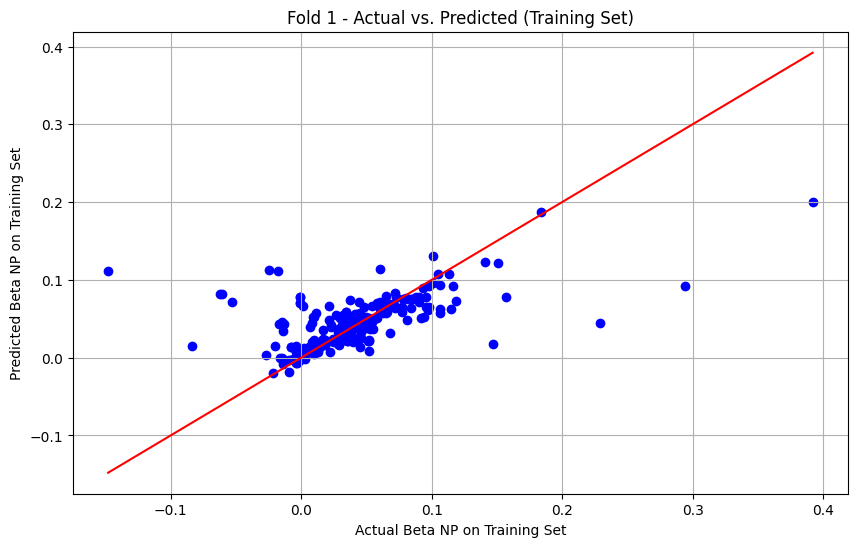

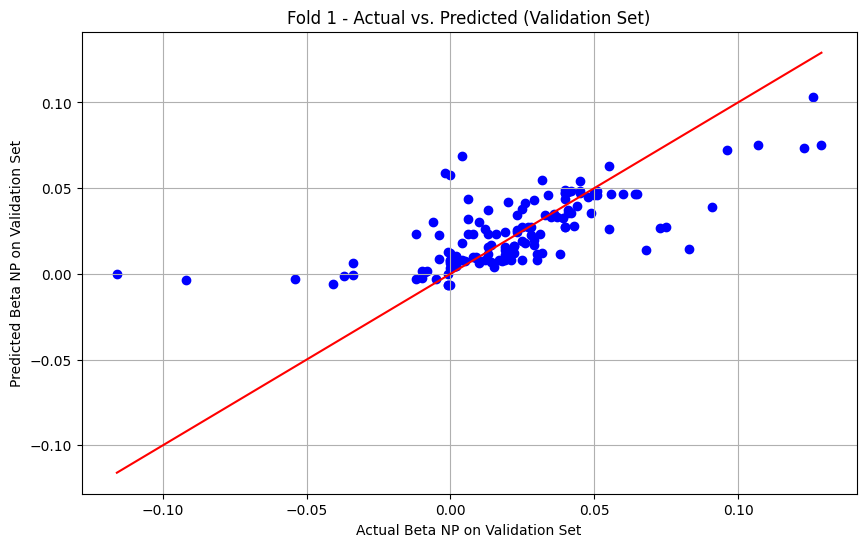

Fold 1 - Train MSE: 0.001887714749891227, Validation MSE: 0.00056639832903647
Fold 2


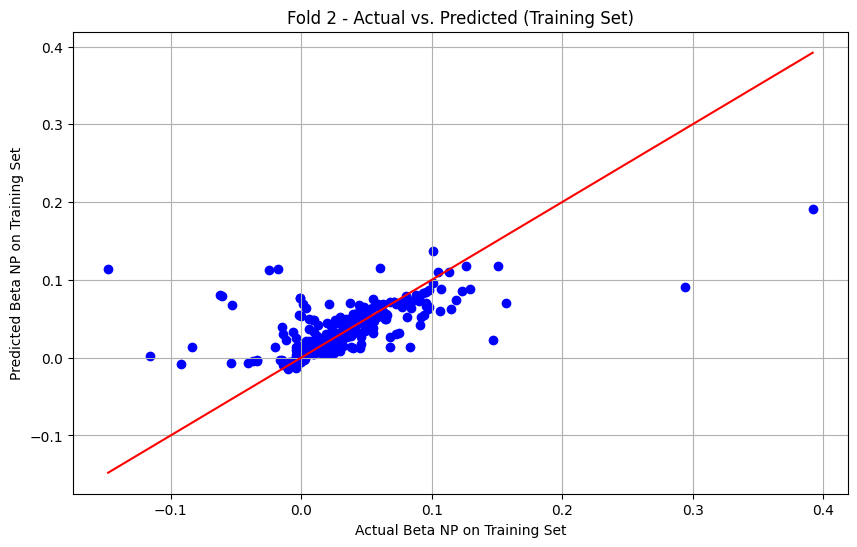

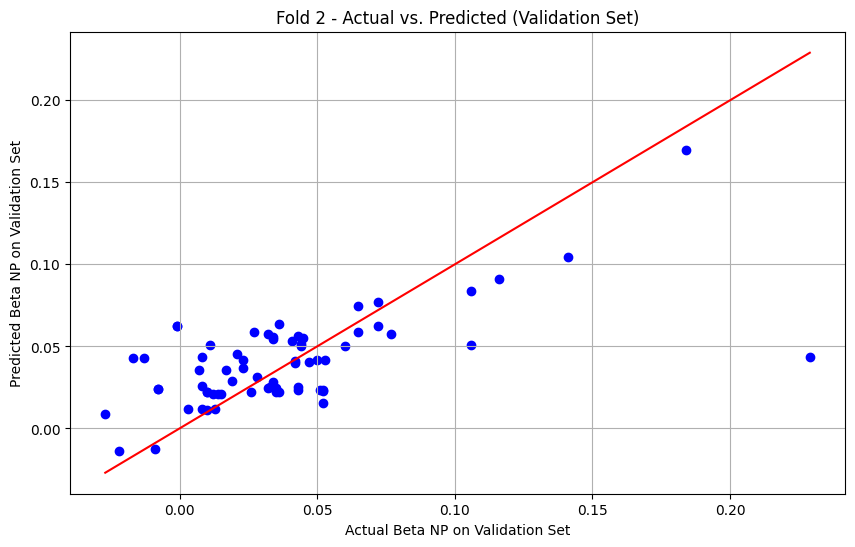

Fold 2 - Train MSE: 0.0014220050247862953, Validation MSE: 0.00109044162529183
Fold 3


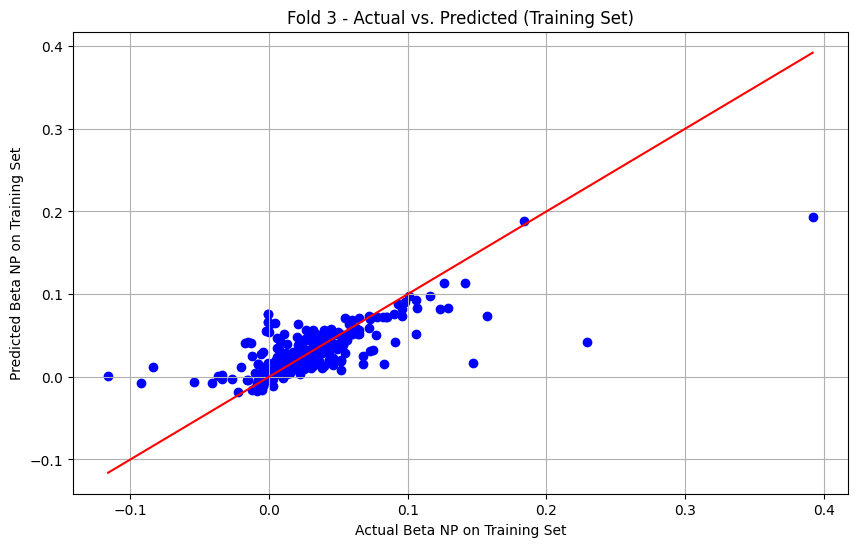

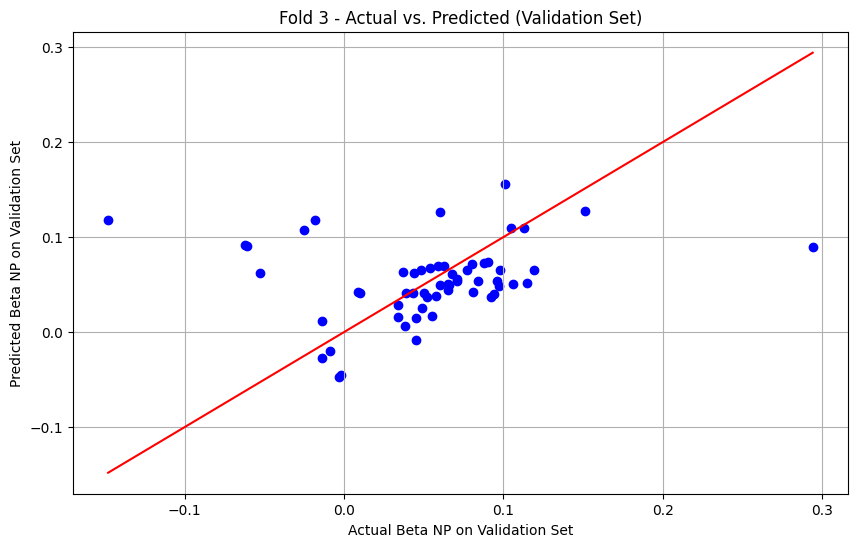

Fold 3 - Train MSE: 0.0008427798984747587, Validation MSE: 0.004445423685425599
Fold 4


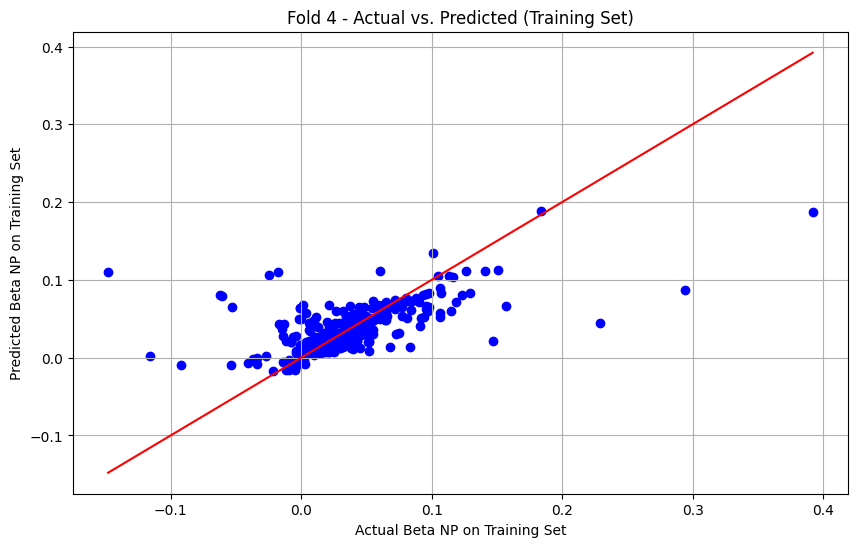

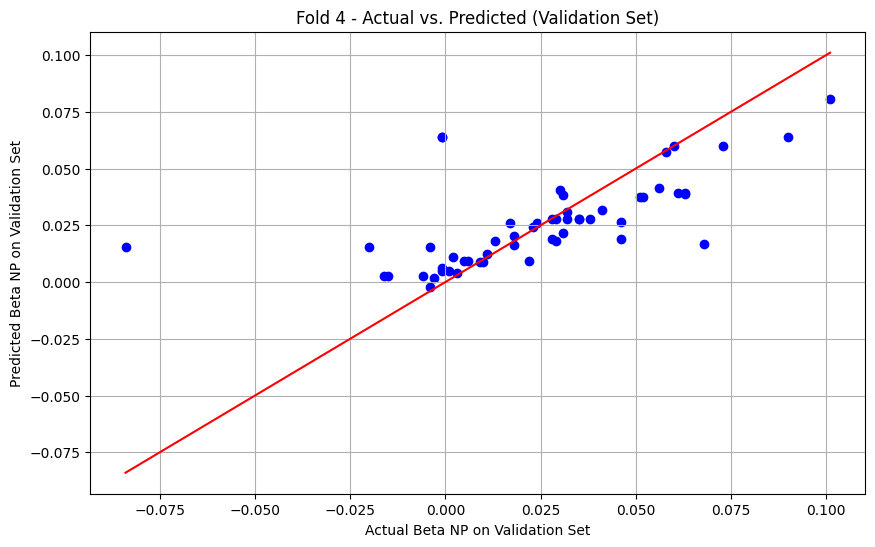

Fold 4 - Train MSE: 0.0014876869398540514, Validation MSE: 0.0005409158058804632
Fold 5


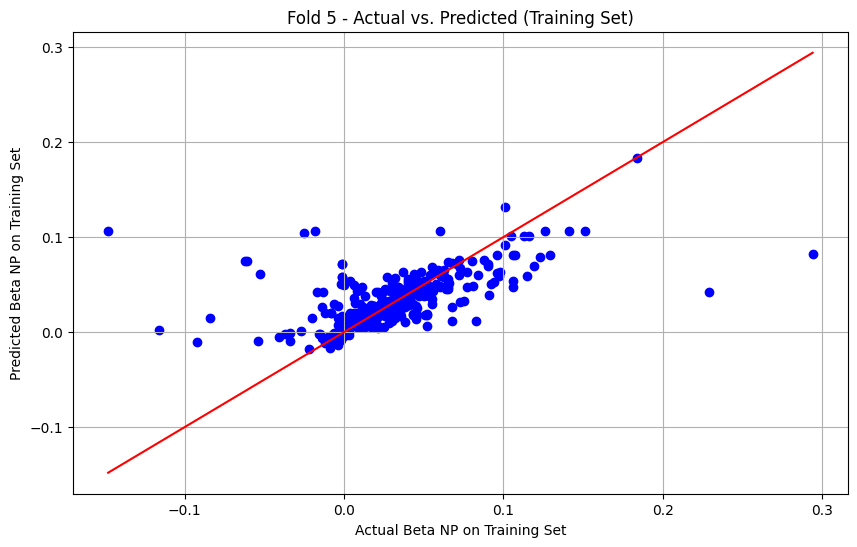

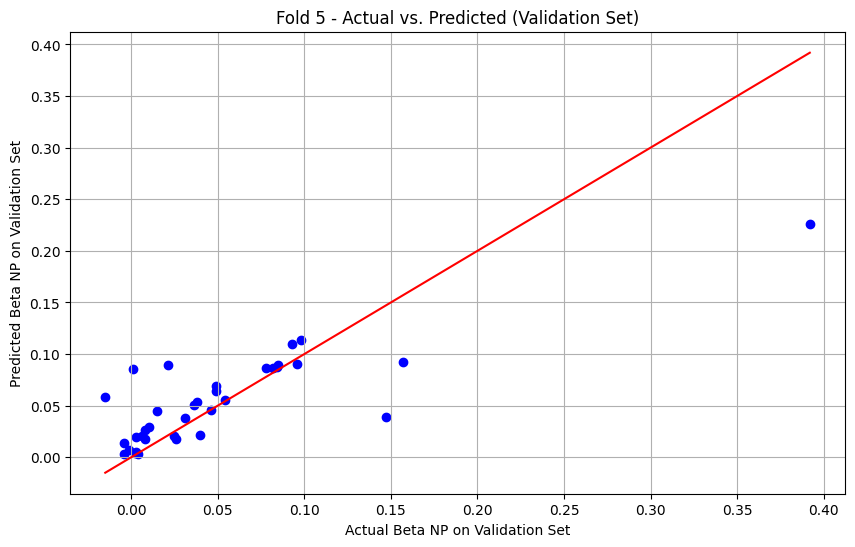

Fold 5 - Train MSE: 0.001232781375564485, Validation MSE: 0.0018697189190700376

Metrics for Train Set for Beta NP Predictor:
Mean MSE: 0.0013745935977141637
Standard Deviation of MSE: 0.0003409597575417465

Metrics for Validation Set for Beta NP Predictor:
Mean MSE: 0.00170257967294088
Standard Deviation of MSE: 0.0014536996099655305


In [ ]:
#Cross Validation on single model Beta NP prediction

#Convert Numpy arrays into Pandas DataFrames
x_train_df2 = pd.DataFrame(x_train2, columns=x_data.columns)
y_train_df2 = pd.DataFrame(y_train2).reset_index(drop=True)

#Define K-fold CV
group_kfold2 = GroupKFold(n_splits=5)

predicted_values2 = np.zeros_like(y_train2)
actual_values2 = np.zeros_like(y_train2)
train_mse_scores2 = []
val_mse_scores2 = []

#Perform K-fold CV with stratification
for fold_idx, (train_index, val_index) in enumerate(group_kfold2.split(x_train_df2, y_train_df2, groups=x_train_df2['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into training and validation folds
  x_train_fold_df2, x_val_fold_df2 = x_train_df2.iloc[train_index], x_train_df2.iloc[val_index]
  y_train_fold_df2, y_val_fold_df2 = y_train_df2.iloc[train_index], y_train_df2.iloc[val_index]
  exp_val2 = train_df2['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold2 = x_train_fold_df2.values
  x_val_fold2 = x_val_fold_df2.values
  y_train_fold2 = y_train_fold_df2.values
  y_val_fold2 = y_val_fold_df2.values

  #Scale data
  scaler_x_train2 = StandardScaler()
  scaler_x_val2 = StandardScaler()

  x_train_fold_scaled2 = scaler_x_train2.fit_transform(x_train_fold2)
  x_val_fold_scaled2 = scaler_x_val2.fit_transform(x_val_fold2)

  scaler_y_train2 = StandardScaler()
  scaler_y_val2 = StandardScaler()

  y_train_fold_scaled2 = scaler_y_train2.fit_transform(y_train_fold2.reshape(-1,1)).flatten()
  y_val_fold_scaled2 = scaler_y_val2.fit_transform(y_val_fold2.reshape(-1,1)).flatten()

  #Fit best model
  best_model2.fit(x_train_fold_scaled2, y_train_fold_scaled2)

  #Make predictions
  y_train_pred_scaled2 = best_model2.predict(x_train_fold_scaled2)
  y_train_pred2 = scaler_y_train2.inverse_transform(y_train_pred_scaled2.reshape(-1,1)).flatten()

  y_val_pred_scaled2 = best_model2.predict(x_val_fold_scaled2)
  y_val_pred2 = scaler_y_val2.inverse_transform(y_val_pred_scaled2.reshape(-1,1)).flatten()

  #Plot predictions on training folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_train_fold2, y_train_pred2, color='blue')
  # plt.xlim(-0.15, 0.4)
  # plt.ylim(-0.15, 0.4)
  plt.plot([min(y_train_fold2), max(y_train_fold2)], [min(y_train_fold2), max(y_train_fold2)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Training Set)")
  plt.xlabel("Actual Beta NP on Training Set")
  plt.ylabel("Predicted Beta NP on Training Set")
  plt.grid(True)
  plt.show()

  y_val_pred_scaled2 = best_model2.predict(x_val_fold_scaled2)
  y_val_pred2 = scaler_y_val2.inverse_transform(y_val_pred_scaled2.reshape(-1,1)).flatten()

  #Plot predictions on validation folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_val_fold2, y_val_pred2, color='blue')
  # plt.xlim(-0.15, 0.4)
  # plt.ylim(-0.15, 0.4)
  plt.plot([min(y_val_fold2), max(y_val_fold2)], [min(y_val_fold2), max(y_val_fold2)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Validation Set)")
  plt.xlabel("Actual Beta NP on Validation Set")
  plt.ylabel("Predicted Beta NP on Validation Set")
  plt.grid(True)
  plt.show()

  #Collect CV results
  train_mse2 = mean_squared_error(y_train_fold2, y_train_pred2)
  val_mse2 = mean_squared_error(y_val_fold2, y_val_pred2)
  train_mse_scores2.append(train_mse2)
  val_mse_scores2.append(val_mse2)
  print(f"Fold {fold_idx + 1} - Train MSE: {train_mse2}, Validation MSE: {val_mse2}")

  #Store CV results
  predicted_values2[val_index] = y_val_pred2.flatten()
  actual_values2[val_index] = y_val_fold2.flatten()

  results_df2 = pd.DataFrame({
      'Exp': train_exp2,
      'Actual Beta NP': actual_values2.flatten(),
      'Predicted Beta NP': predicted_values2.flatten()
  })

results_df2.to_excel('predicted_values_cv2.xlsx', index=False)

#CV metrics
mean_train_mse2 = np.mean(train_mse_scores2)
std_train_mse2 = np.std(train_mse_scores2)

mean_val_mse2 = np.mean(val_mse_scores2)
std_val_mse2 = np.std(val_mse_scores2)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for Beta NP Predictor:")
print("Mean MSE:", mean_train_mse2)
print("Standard Deviation of MSE:", std_train_mse2)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for Beta NP Predictor:")
print("Mean MSE:", mean_val_mse2)
print("Standard Deviation of MSE:", std_val_mse2)

***Ensembling approach***

Fold 1


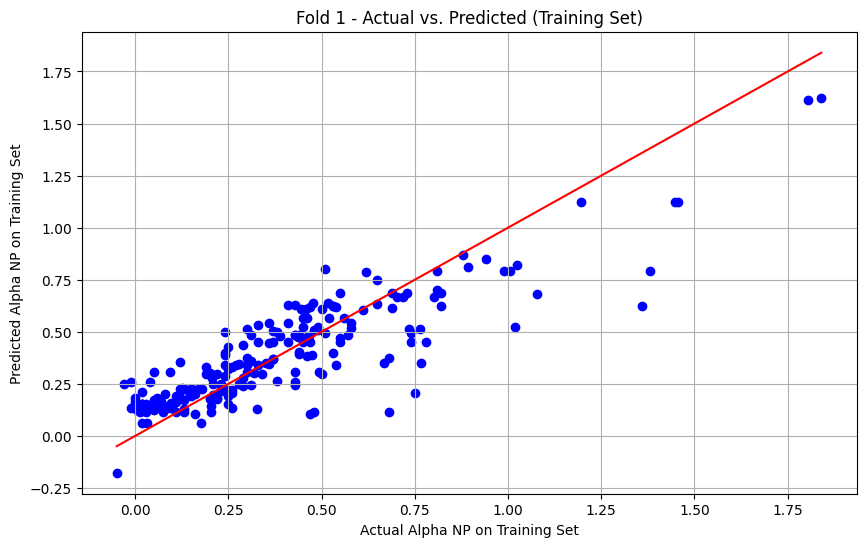

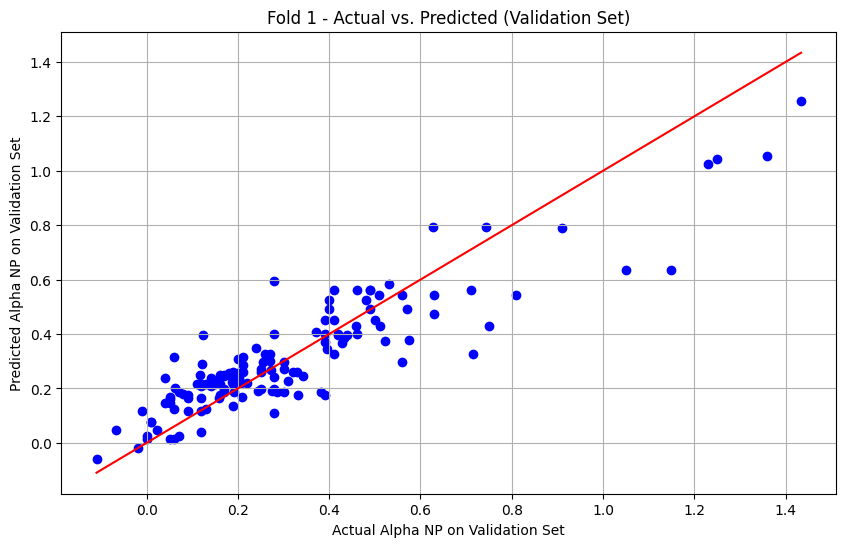

Fold 1 - Train MSE: 0.026180165105468747, Validation MSE: 0.015555290364942704
Fold 1 - Train R2: 0.7512651662742191, Validation R2: 0.7944061898040354
Fold 2


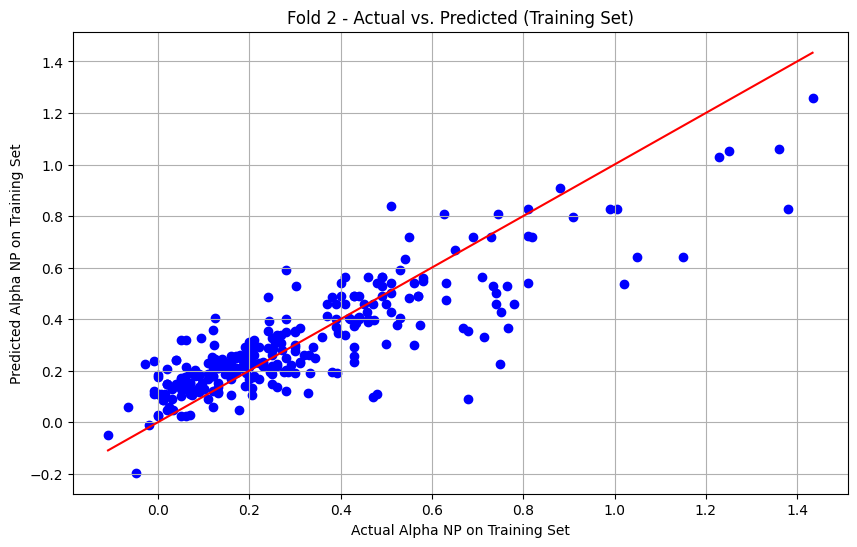

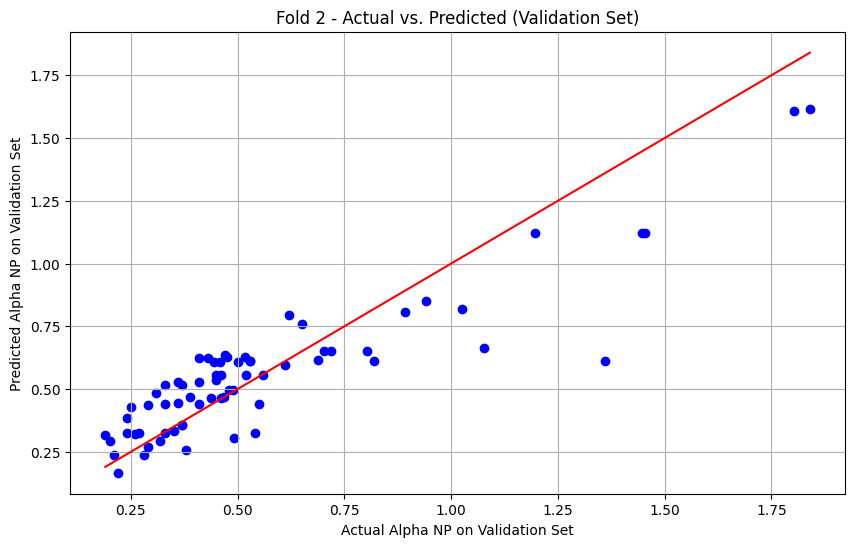

Fold 2 - Train MSE: 0.020318938944688628, Validation MSE: 0.027156475424763654
Fold 2 - Train R2: 0.7257848730719427, Validation R2: 0.7890130260587835
Fold 3


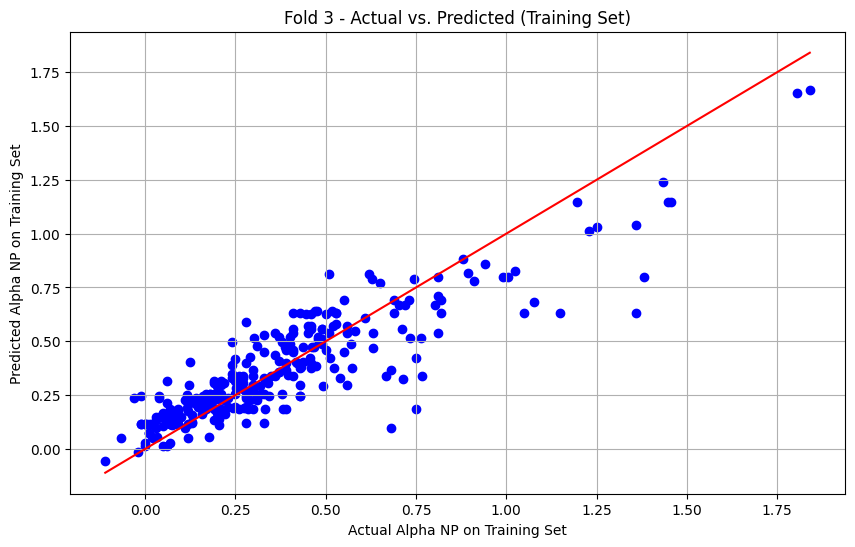

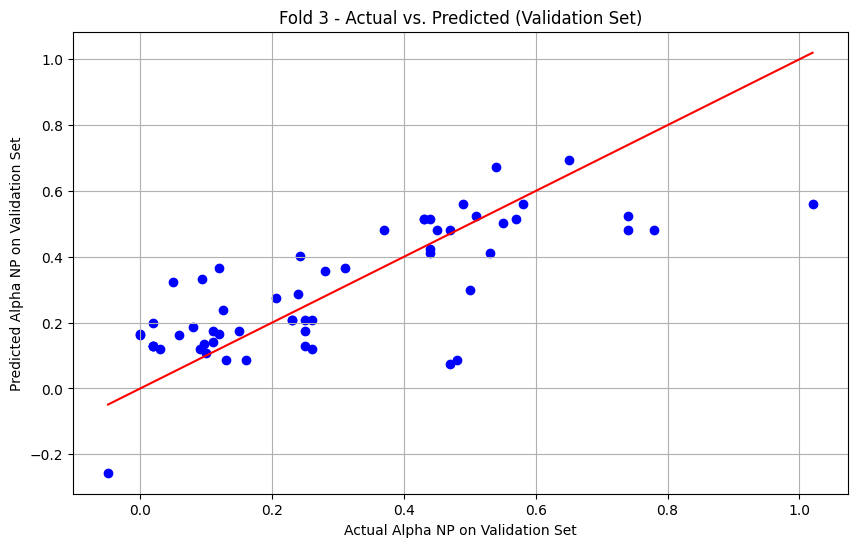

Fold 3 - Train MSE: 0.021759992826454883, Validation MSE: 0.023288003997597714
Fold 3 - Train R2: 0.7856242844709689, Validation R2: 0.5796676961428424
Fold 4


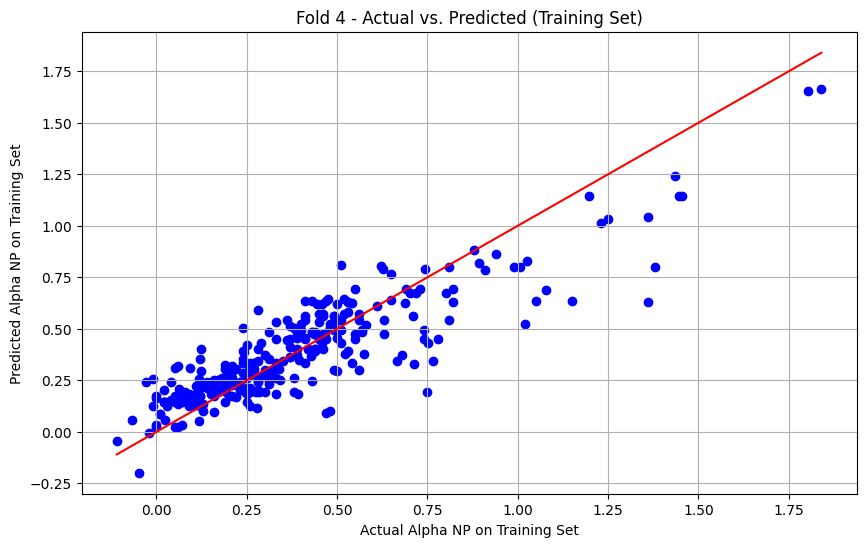

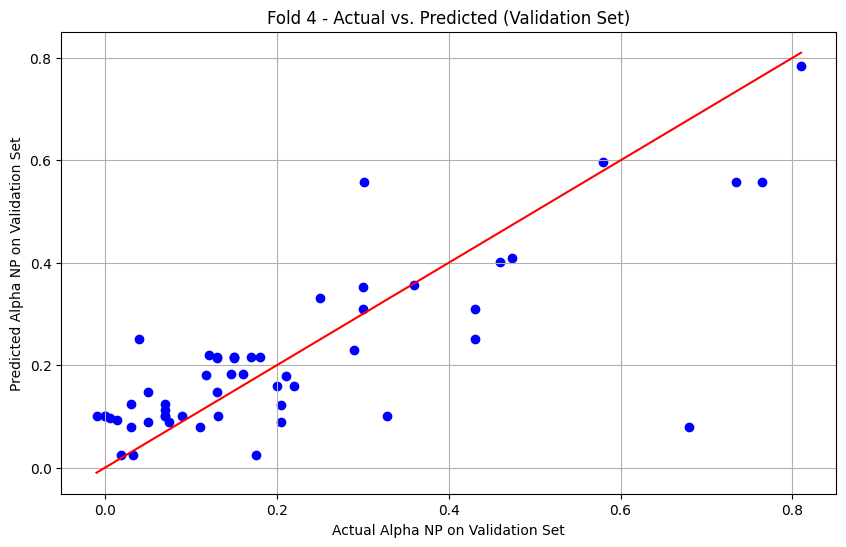

Fold 4 - Train MSE: 0.02298396000578728, Validation MSE: 0.01559646024473129
Fold 4 - Train R2: 0.7699690956817562, Validation R2: 0.6192683058366422
Fold 5


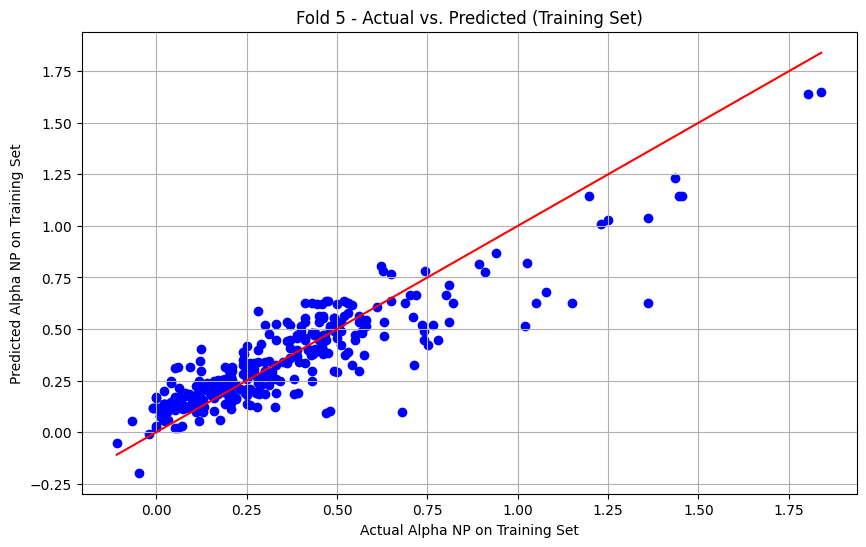

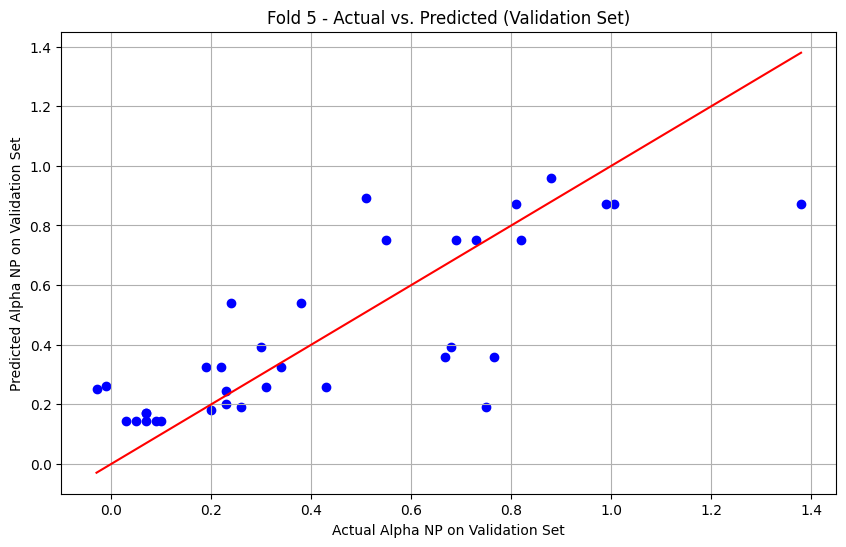

Fold 5 - Train MSE: 0.01949788615636788, Validation MSE: 0.044336634037785205
Fold 5 - Train R2: 0.7859382942717292, Validation R2: 0.6325896317510029

Metrics for Train Set for Alpha NP Predictor:
Mean MSE: 0.022148188607753486
Standard Deviation of MSE: 0.0023441971626192654
Mean R2: 0.7637163427541234
Standard Deviation of R2: 0.022832862924641997

Metrics for Validation Set for Alpha NP Predictor:
Mean MSE: 0.025186572813964116
Standard Deviation of MSE: 0.010573001328156497
Mean R2: 0.6829889699186612
Standard Deviation of R2: 0.09047717867046788


In [ ]:
#Transform Ensemble Alpha NP predictions into a regular model

#Train independant models on the whole Train Set
final_model1a = best_model1a.fit(x_train1, y_train1)
final_model1b = best_model1b.fit(x_train1, y_train1)
final_model1c = best_model1c.fit(x_train1, y_train1)
final_model1d = best_model1d.fit(x_train1, y_train1)

#Define optimal weights for each model on the ensembling
optimized_weights1 = [0.00, 0.00, 0.00, 1.00]

#Define EnsembleRegressor
class EnsembleRegressor(BaseEstimator, RegressorMixin):
  def __init__(self, models=None, weights=None):
    self.models = models
    self.weights = weights

  def fit(self, x_train1, y_train1):
    for model in self.models:
      model.fit(x_train1, y_train1)
    return self

  def predict(self, x_train1):
    predictions1 = []
    for model in self.models:
      predictions1.append(model.predict(x_train1))
    if self.weights is None:
      weights = [1.0 / len(self.models)] * len(self.models)
    else:
      weights = self.weights
    ensemble_prediction1 = sum(w * pred for w, pred in zip(weights, predictions1))
    return ensemble_prediction1

#Define and fit ensemble model
ensemble_model1 = EnsembleRegressor(models=[final_model1a, final_model1b, final_model1c, final_model1d], weights=optimized_weights1)
ensemble_model1.fit(x_train1, y_train1)
ensemble_model1.predict(x_train1)

#Convert Numpy arrays into Pandas DataFrames
x_train_df1 = pd.DataFrame(x_train1, columns=x_data.columns)
y_train_df1 = pd.DataFrame(y_train1).reset_index(drop=True)

#Define K-fold CV
group_kfold1 = GroupKFold(n_splits=5)

predicted_values1 = np.zeros_like(y_train1)
actual_values1 = np.zeros_like(y_train1)
train_mse_scores1 = []
val_mse_scores1 = []
train_r2_scores1 = []
val_r2_scores1 = []

#Perform K-fold CV with stratification
for fold_idx, (train_index, val_index) in enumerate(group_kfold1.split(x_train_df1, y_train_df1, groups=x_train_df1['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into Training and Validation folds
  x_train_fold_df1, x_val_fold_df1 = x_train_df1.iloc[train_index], x_train_df1.iloc[val_index]
  y_train_fold_df1, y_val_fold_df1 = y_train_df1.iloc[train_index], y_train_df1.iloc[val_index]
  exp_val1 = train_df1['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold1 = x_train_fold_df1.values
  x_val_fold1 = x_val_fold_df1.values
  y_train_fold1 = y_train_fold_df1.values
  y_val_fold1 = y_val_fold_df1.values

  #Scale data
  scaler_x_train1 = StandardScaler()
  scaler_x_val1 = StandardScaler()

  x_train_fold_scaled1 = scaler_x_train1.fit_transform(x_train_fold1)
  x_val_fold_scaled1 = scaler_x_val1.fit_transform(x_val_fold1)

  scaler_y_train1 = StandardScaler()
  scaler_y_val1 = StandardScaler()

  y_train_fold_scaled1 = scaler_y_train1.fit_transform(y_train_fold1.reshape(-1,1)).flatten()
  y_val_fold_scaled1 = scaler_y_val1.fit_transform(y_val_fold1.reshape(-1,1)).flatten()

  #Fit ensemble model
  ensemble_model1.fit(x_train_fold_scaled1, y_train_fold_scaled1)

  #Make predictions
  y_train_pred_scaled1 = ensemble_model1.predict(x_train_fold_scaled1)
  y_train_pred1 = scaler_y_train1.inverse_transform(y_train_pred_scaled1.reshape(-1,1)).flatten()

  y_val_pred_scaled1 = ensemble_model1.predict(x_val_fold_scaled1)
  y_val_pred1 = scaler_y_val1.inverse_transform(y_val_pred_scaled1.reshape(-1,1)).flatten()

  #Plot predictions on training folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_train_fold1, y_train_pred1, color='blue')
  # plt.xlim(-0.12, 1.4)
  # plt.ylim(-0.12, 1.4)
  plt.plot([min(y_train_fold1), max(y_train_fold1)], [min(y_train_fold1), max(y_train_fold1)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Training Set)")
  plt.xlabel("Actual Alpha NP on Training Set")
  plt.ylabel("Predicted Alpha NP on Training Set")
  plt.grid(True)
  plt.show()

  y_val_pred_scaled1 = ensemble_model1.predict(x_val_fold_scaled1)
  y_val_pred1 = scaler_y_val1.inverse_transform(y_val_pred_scaled1.reshape(-1,1)).flatten()

  #Plot predictions on validation folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_val_fold1, y_val_pred1, color='blue')
  # plt.xlim(-0.12, 1.4)
  # plt.ylim(-0.12, 1.4)
  plt.plot([min(y_val_fold1), max(y_val_fold1)], [min(y_val_fold1), max(y_val_fold1)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Validation Set)")
  plt.xlabel("Actual Alpha NP on Validation Set")
  plt.ylabel("Predicted Alpha NP on Validation Set")
  plt.grid(True)
  plt.show()

  #Collect CV results
  train_mse1 = mean_squared_error(y_train_fold1, y_train_pred1)
  val_mse1 = mean_squared_error(y_val_fold1, y_val_pred1)
  train_mse_scores1.append(train_mse1)
  val_mse_scores1.append(val_mse1)

  train_r2_score1 = r2_score(y_train_fold1, y_train_pred1)
  val_r2_score1 = r2_score(y_val_fold1, y_val_pred1)
  train_r2_scores1.append(train_r2_score1)
  val_r2_scores1.append(val_r2_score1)

  print(f"Fold {fold_idx + 1} - Train MSE: {train_mse1}, Validation MSE: {val_mse1}")
  print(f"Fold {fold_idx + 1} - Train R2: {train_r2_score1}, Validation R2: {val_r2_score1}")

  #Store CV results
  predicted_values1[val_index] = y_val_pred1.flatten()
  actual_values1[val_index] = y_val_fold1.flatten()

  results_df1 = pd.DataFrame({
      'Exp': train_exp1,
      'Actual Alpha NP': actual_values1.flatten(),
      'Predicted Alpha NP': predicted_values1.flatten()
  })

results_df1.to_excel('predicted_values_cv1.xlsx', index=False)

#CV metrics
mean_train_mse1 = np.mean(train_mse_scores1)
std_train_mse1 = np.std(train_mse_scores1)

mean_val_mse1 = np.mean(val_mse_scores1)
std_val_mse1 = np.std(val_mse_scores1)

mean_train_r2_score1 = np.mean(train_r2_scores1)
std_r2_score1 = np.std(train_r2_scores1)

mean_val_r2_score1 = np.mean(val_r2_scores1)
std_val_r2_score1 = np.std(val_r2_scores1)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for Alpha NP Predictor:")
print("Mean MSE:", mean_train_mse1)
print("Standard Deviation of MSE:", std_train_mse1)
print("Mean R2:", mean_train_r2_score1)
print("Standard Deviation of R2:", std_r2_score1)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for Alpha NP Predictor:")
print("Mean MSE:", mean_val_mse1)
print("Standard Deviation of MSE:", std_val_mse1)
print("Mean R2:", mean_val_r2_score1)
print("Standard Deviation of R2:", std_val_r2_score1)

Fold 1


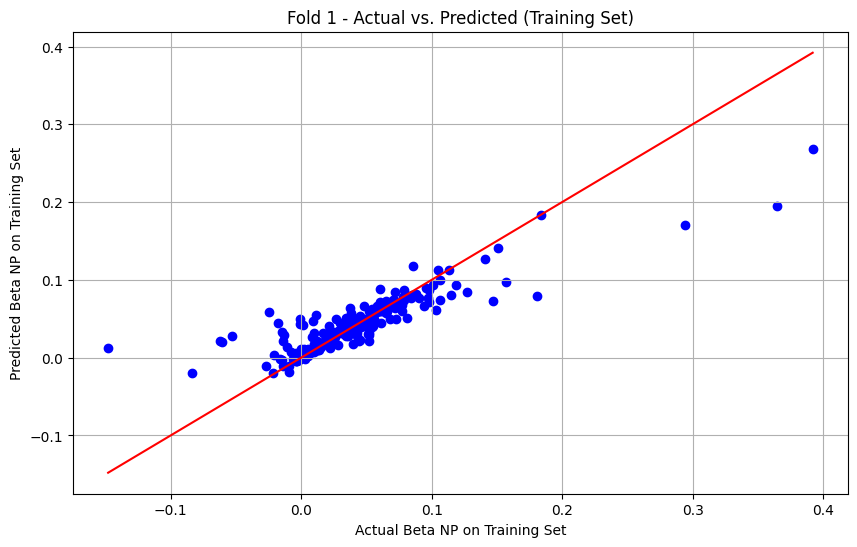

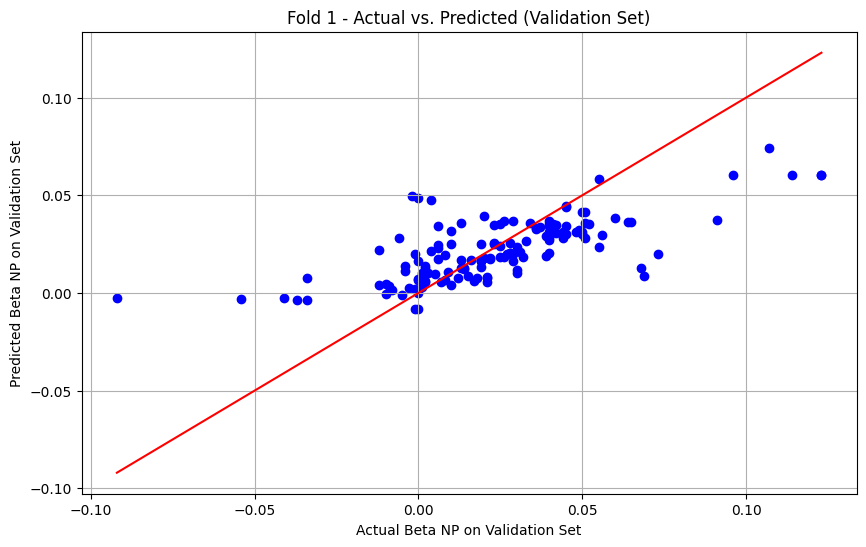

Fold 1 - Train MSE: 0.0008483872713982148, Validation MSE: 0.0004848806493691121
Fold 1 - Train R2: 0.732753136568701, Validation R2: 0.48190736172839443
Fold 2


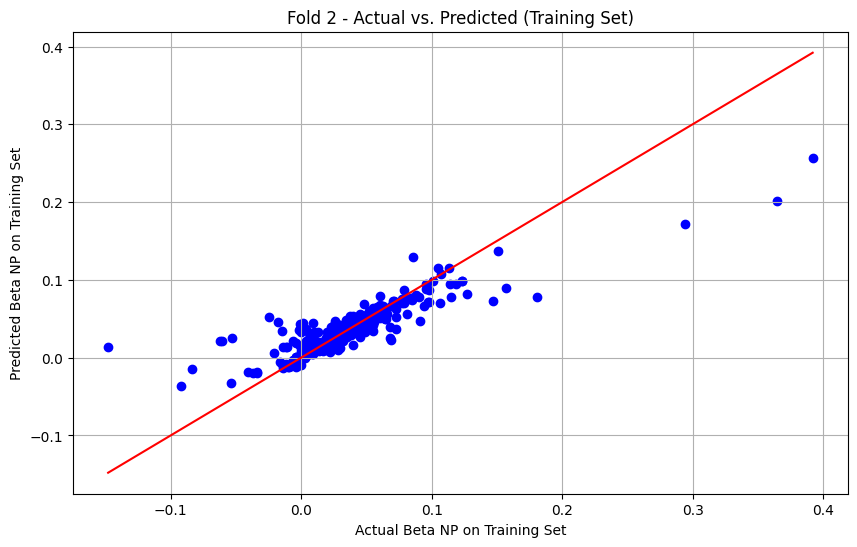

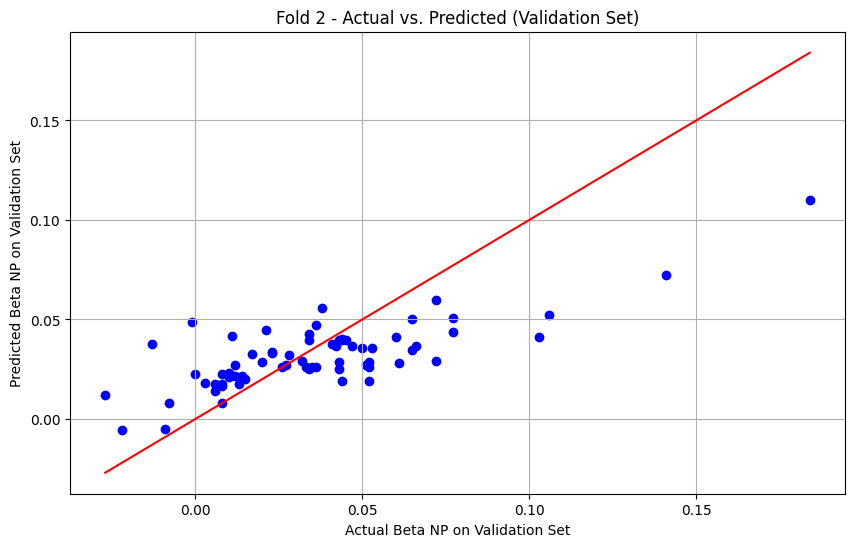

Fold 2 - Train MSE: 0.0006828539559481079, Validation MSE: 0.0006037599216011072
Fold 2 - Train R2: 0.7407902132435327, Validation R2: 0.5027716767775994
Fold 3


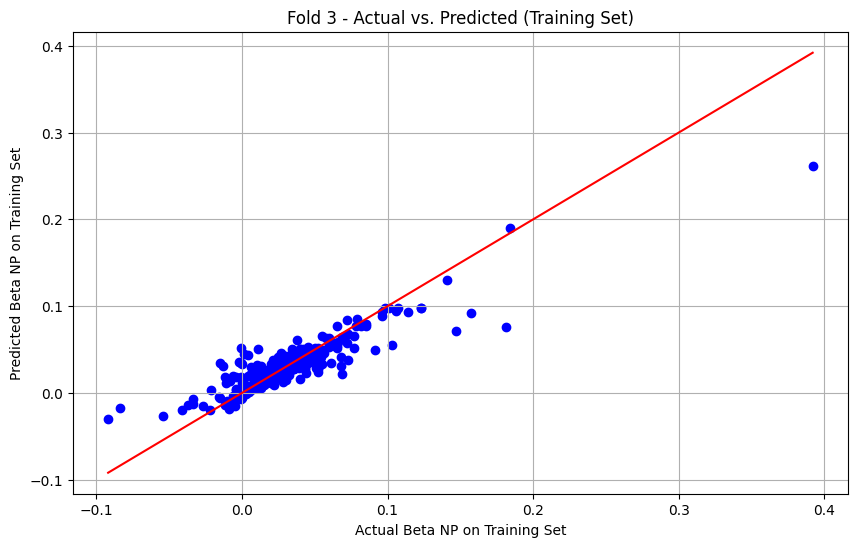

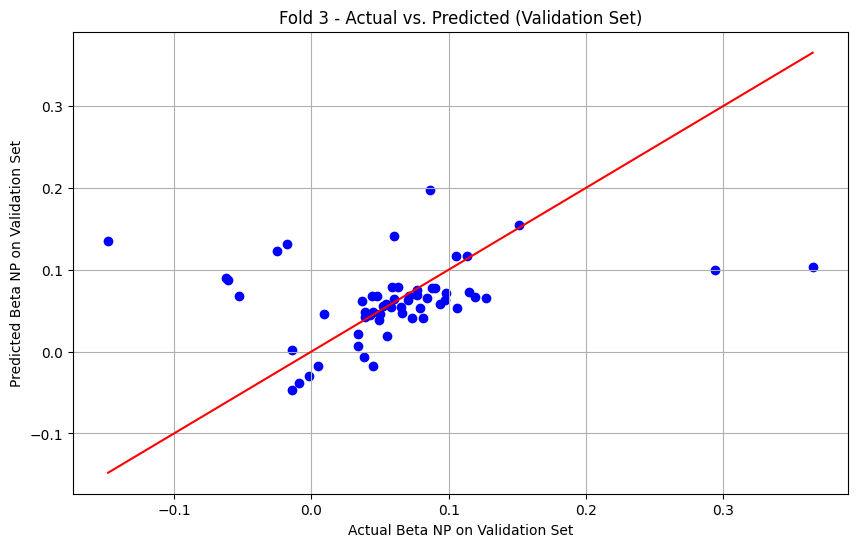

Fold 3 - Train MSE: 0.00033542828505300705, Validation MSE: 0.0059222297604531364
Fold 3 - Train R2: 0.7966706420037213, Validation R2: -0.10289976011831681
Fold 4


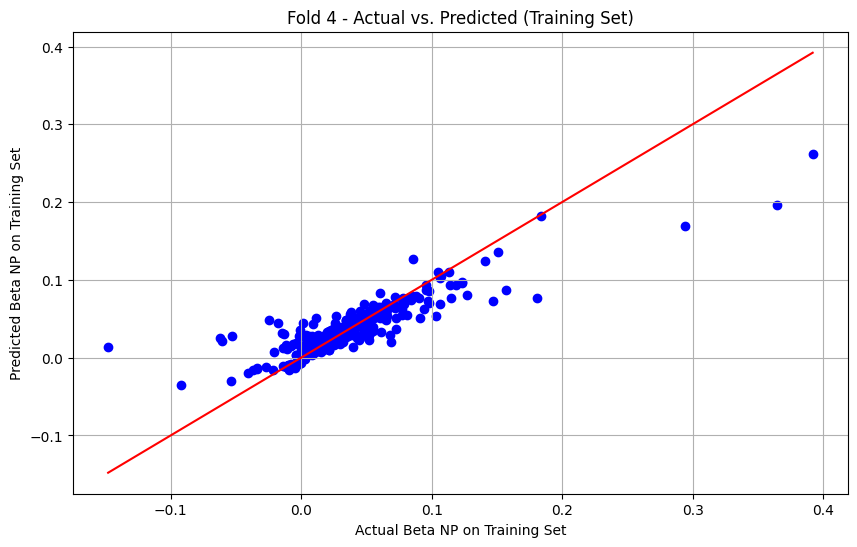

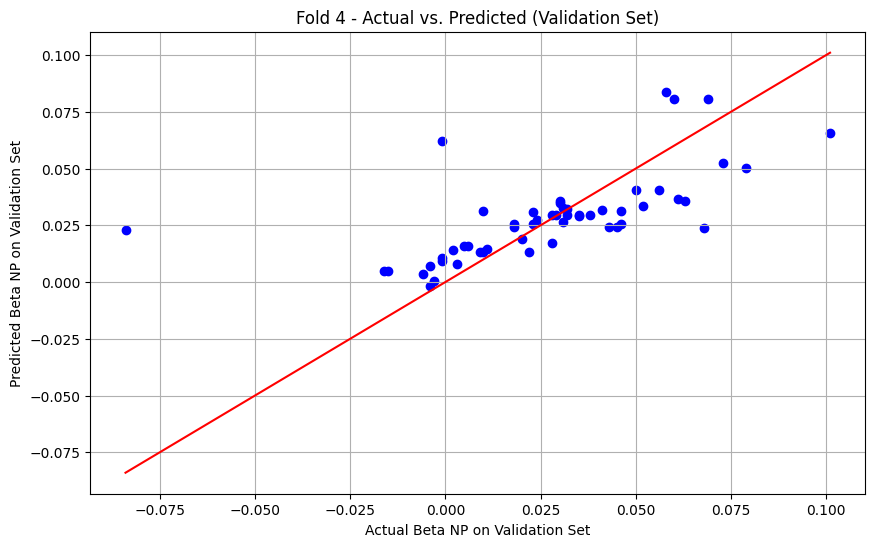

Fold 4 - Train MSE: 0.0006755440519651438, Validation MSE: 0.0005077664593537442
Fold 4 - Train R2: 0.7416368200042188, Validation R2: 0.4269598232573866
Fold 5


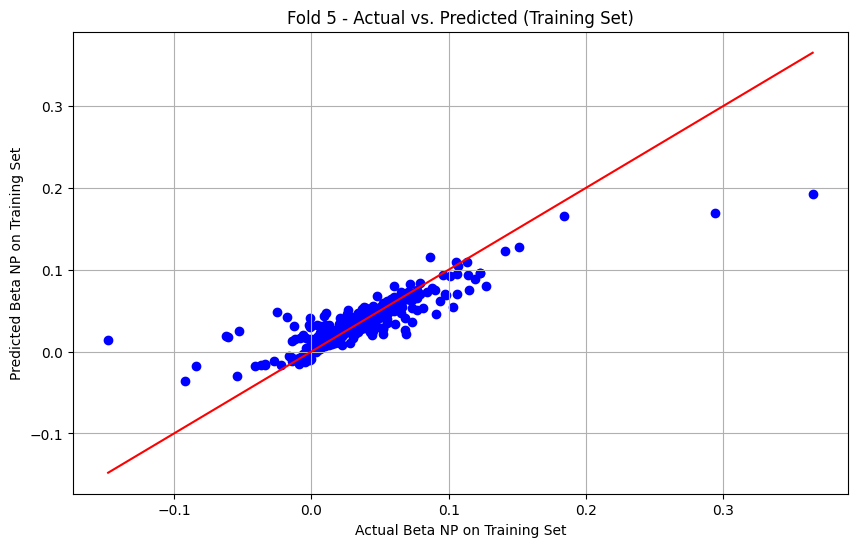

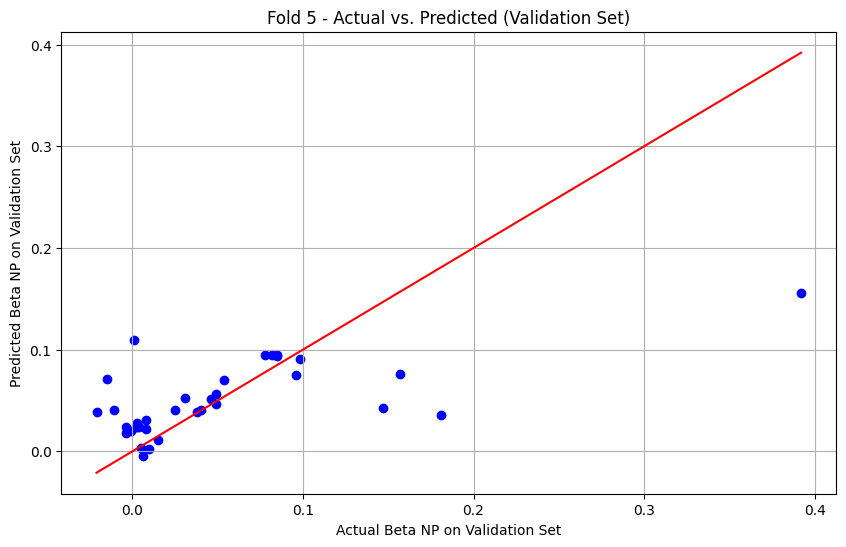

Fold 5 - Train MSE: 0.0005242626186539067, Validation MSE: 0.0036021629399511663
Fold 5 - Train R2: 0.7309859057603418, Validation R2: 0.39356409484622146

Metrics for Train Set for Beta NP Predictor:
Mean MSE: 0.000613295236603676
Standard Deviation of MSE: 0.00017269536478876994
Mean R2: 0.7485673435161031
Standard Deviation of R2: 0.024419825272713032

Metrics for Validation Set for Beta NP Predictor:
Mean MSE: 0.0022241599461456534
Standard Deviation of MSE: 0.0021986999756979254
Mean R2: 0.34046063929825704
Standard Deviation of R2: 0.22504336371526384


In [ ]:
#Transform Ensemble Beta NP predictions into a regular model

#Train independant models on the whole Train Set
final_model2a = best_model2a.fit(x_train2, y_train2)
final_model2b = best_model2b.fit(x_train2, y_train2)
final_model2c = best_model2c.fit(x_train2, y_train2)
final_model2d = best_model2d.fit(x_train2, y_train2)

#Define optimal weights for every model of the ensembling
optimized_weights2 = [0.00, 0.00, 0.00, 1.00]

#Define EnsembleRegressor
class EnsembleRegressor(BaseEstimator, RegressorMixin):
  def __init__(self, models=None, weights=None):
    self.models = models
    self.weights = weights

  def fit(self, x_train2, y_train2):
    for model in self.models:
      model.fit(x_train2, y_train2)
    return self

  def predict(self, x_train2):
    predictions2 = []
    for model in self.models:
      predictions2.append(model.predict(x_train2))
    if self.weights is None:
      weights = [1.0 / len(self.models)] * len(self.models)
    else:
      weights = self.weights
    ensemble_prediction2 = sum(w * pred for w, pred in zip(weights, predictions2))
    return ensemble_prediction2

#Define and fit ensemble model
ensemble_model2 = EnsembleRegressor(models=[final_model2a, final_model2b, final_model2c, final_model2d], weights=optimized_weights2)
ensemble_model2.fit(x_train2, y_train2)
ensemble_model2.predict(x_train2)

#Convert Numpy arrays into Pandas DataFrames
x_train_df2 = pd.DataFrame(x_train2, columns=x_data.columns)
y_train_df2 = pd.DataFrame(y_train2).reset_index(drop=True)

#Define K-fold CV
group_kfold2 = GroupKFold(n_splits=5)

predicted_values2 = np.zeros_like(y_train2)
actual_values2 = np.zeros_like(y_train2)
train_mse_scores2 = []
val_mse_scores2 = []
train_r2_scores2 = []
val_r2_scores2 = []

#Perform K-fold CV with stratification
for fold_idx, (train_index, val_index) in enumerate(group_kfold2.split(x_train_df2, y_train_df2, groups=x_train_df2['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into training and validation folds
  x_train_fold_df2, x_val_fold_df2 = x_train_df2.iloc[train_index], x_train_df2.iloc[val_index]
  y_train_fold_df2, y_val_fold_df2 = y_train_df2.iloc[train_index], y_train_df2.iloc[val_index]
  exp_val2 = train_df2['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold2 = x_train_fold_df2.values
  x_val_fold2 = x_val_fold_df2.values
  y_train_fold2 = y_train_fold_df2.values
  y_val_fold2 = y_val_fold_df2.values

  #Scale data
  scaler_x_train2 = StandardScaler()
  scaler_x_val2 = StandardScaler()

  x_train_fold_scaled2 = scaler_x_train2.fit_transform(x_train_fold2)
  x_val_fold_scaled2 = scaler_x_val2.fit_transform(x_val_fold2)

  scaler_y_train2 = StandardScaler()
  scaler_y_val2 = StandardScaler()

  y_train_fold_scaled2 = scaler_y_train2.fit_transform(y_train_fold2.reshape(-1,1)).flatten()
  y_val_fold_scaled2 = scaler_y_val2.fit_transform(y_val_fold2.reshape(-1,1)).flatten()

  #Fit ensemble model
  ensemble_model2.fit(x_train_fold_scaled2, y_train_fold_scaled2)

  #Make predictions
  y_train_pred_scaled2 = ensemble_model2.predict(x_train_fold_scaled2)
  y_train_pred2 = scaler_y_train2.inverse_transform(y_train_pred_scaled2.reshape(-1,1)).flatten()

  y_val_pred_scaled2 = ensemble_model2.predict(x_val_fold_scaled2)
  y_val_pred2 = scaler_y_val2.inverse_transform(y_val_pred_scaled2.reshape(-1,1)).flatten()

  #Plot predictions on training folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_train_fold2, y_train_pred2, color='blue')
  # plt.xlim(-0.15, 0.4)
  # plt.ylim(-0.15, 0.4)
  plt.plot([min(y_train_fold2), max(y_train_fold2)], [min(y_train_fold2), max(y_train_fold2)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Training Set)")
  plt.xlabel("Actual Beta NP on Training Set")
  plt.ylabel("Predicted Beta NP on Training Set")
  plt.grid(True)
  plt.show()

  y_val_pred_scaled2 = ensemble_model2.predict(x_val_fold_scaled2)
  y_val_pred2 = scaler_y_val2.inverse_transform(y_val_pred_scaled2.reshape(-1,1)).flatten()

  #Plot predictions on validation folds
  plt.figure(figsize=(10,6))
  plt.scatter(y_val_fold2, y_val_pred2, color='blue')
  # plt.xlim(-0.15, 0.4)
  # plt.ylim(-0.15, 0.4)
  plt.plot([min(y_val_fold2), max(y_val_fold2)], [min(y_val_fold2), max(y_val_fold2)], color='red')
  plt.title(f"Fold {fold_idx + 1} - Actual vs. Predicted (Validation Set)")
  plt.xlabel("Actual Beta NP on Validation Set")
  plt.ylabel("Predicted Beta NP on Validation Set")
  plt.grid(True)
  plt.show()

  #Collect CV results
  train_mse2 = mean_squared_error(y_train_fold2, y_train_pred2)
  val_mse2 = mean_squared_error(y_val_fold2, y_val_pred2)
  train_mse_scores2.append(train_mse2)
  val_mse_scores2.append(val_mse2)

  train_r2_score2 = r2_score(y_train_fold2, y_train_pred2)
  val_r2_score2 = r2_score(y_val_fold2, y_val_pred2)
  train_r2_scores2.append(train_r2_score2)
  val_r2_scores2.append(val_r2_score2)
  print(f"Fold {fold_idx + 1} - Train MSE: {train_mse2}, Validation MSE: {val_mse2}")
  print(f"Fold {fold_idx + 1} - Train R2: {train_r2_score2}, Validation R2: {val_r2_score2}")

  #Store CV results
  predicted_values2[val_index] = y_val_pred2.flatten()
  actual_values2[val_index] = y_val_fold2.flatten()

  results_df2 = pd.DataFrame({
      'Exp': train_exp2,
      'Actual Beta NP': actual_values2.flatten(),
      'Predicted Beta NP': predicted_values2.flatten()
  })

results_df2.to_excel('predicted_values_cv2.xlsx', index=False)

#CV metrics
mean_train_mse2 = np.mean(train_mse_scores2)
std_train_mse2 = np.std(train_mse_scores2)

mean_val_mse2 = np.mean(val_mse_scores2)
std_val_mse2 = np.std(val_mse_scores2)

mean_train_r2_score2 = np.mean(train_r2_scores2)
std_train_r2_score2 = np.std(train_r2_scores2)

mean_val_r2_score2 = np.mean(val_r2_scores2)
std_val_r2_score2 = np.std(val_r2_scores2)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for Beta NP Predictor:")
print("Mean MSE:", mean_train_mse2)
print("Standard Deviation of MSE:", std_train_mse2)
print("Mean R2:", mean_train_r2_score2)
print("Standard Deviation of R2:", std_train_r2_score2)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for Beta NP Predictor:")
print("Mean MSE:", mean_val_mse2)
print("Standard Deviation of MSE:", std_val_mse2)
print("Mean R2:", mean_val_r2_score2)
print("Standard Deviation of R2:", std_val_r2_score2)

**STEP 6 - ANALYZE PREDICTIONS ON FULL TRAINING SET**

In this section, the five folds of the cross-validation are regrouped in order to get the predictions for the full validation set. This step is executed in the same cells for a single model approach or an ensembling approach.

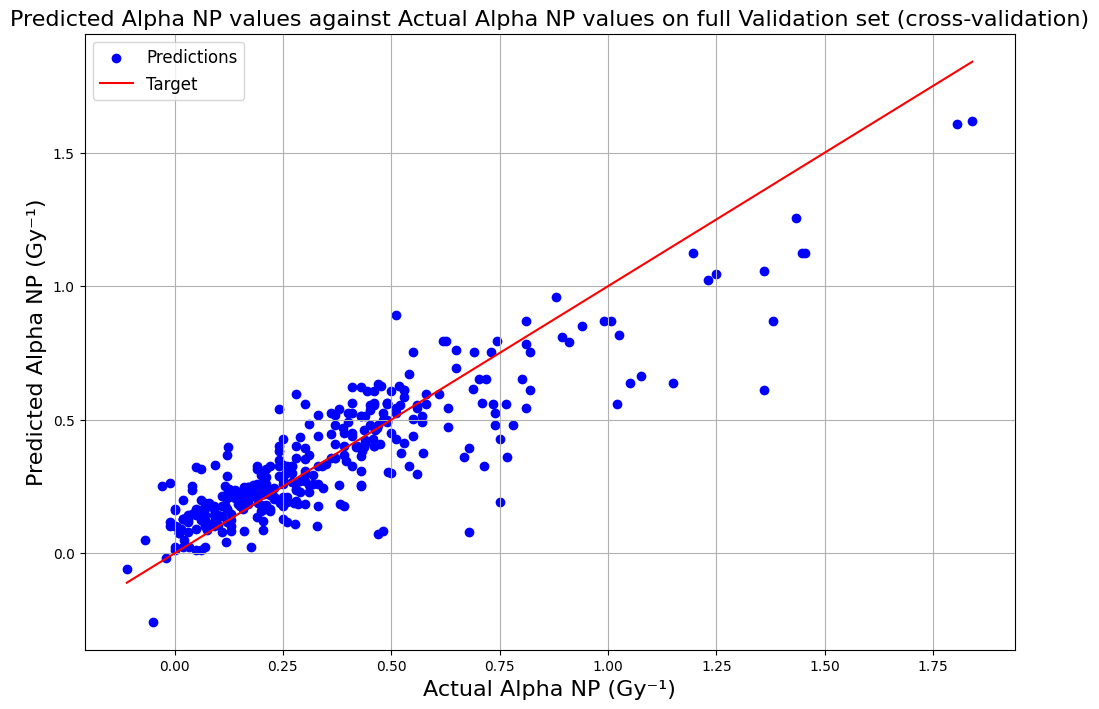

Pearson correlation coefficient:  0.8798764158287694
Pearson p-value:  9.412715585064165e-117
Spearman correlation coefficient:  0.8432726315910387
Spearman p-value:  9.55912432955048e-98


In [ ]:
#Predictions on full train set for Alpha NP

#Import CV predictions
data_cv1 = pd.read_excel("predicted_values_cv1.xlsx")

#Define input and output
x_data_cv1 = data_cv1['Actual Alpha NP']
y_data_cv1 = data_cv1['Predicted Alpha NP']

#Plot predictions against actual values for Alpha NP on full Train subset
plt.figure(figsize=(12,8))
plt.title("Predicted Alpha NP values against Actual Alpha NP values on full Validation set (cross-validation)", fontsize=16)
plt.scatter(x_data_cv1, y_data_cv1, marker='o', color='blue', label='Predictions')
plt.plot([min(x_data_cv1), max(x_data_cv1)],[min(x_data_cv1), max(x_data_cv1)], color='red', label='Target')
plt.xlabel("Actual Alpha NP (Gy\u207B\u00B9)", fontsize=16)
plt.ylabel("Predicted Alpha NP (Gy\u207B\u00B9)", fontsize=16)
plt.legend(fontsize='large')
plt.grid(True)
plt.show()

#Print Pearson and Spearman correlation coefficients and p-values
pearson_cv_corr1, pearson_cv_p_value1 = pearsonr(x_data_cv1, y_data_cv1)
print("Pearson correlation coefficient: ", pearson_cv_corr1)
print("Pearson p-value: ", pearson_cv_p_value1)

spearman_cv_corr1, spearman_cv_p_value1 = spearmanr(x_data_cv1, y_data_cv1)
print("Spearman correlation coefficient: ", spearman_cv_corr1)
print("Spearman p-value: ", spearman_cv_p_value1)

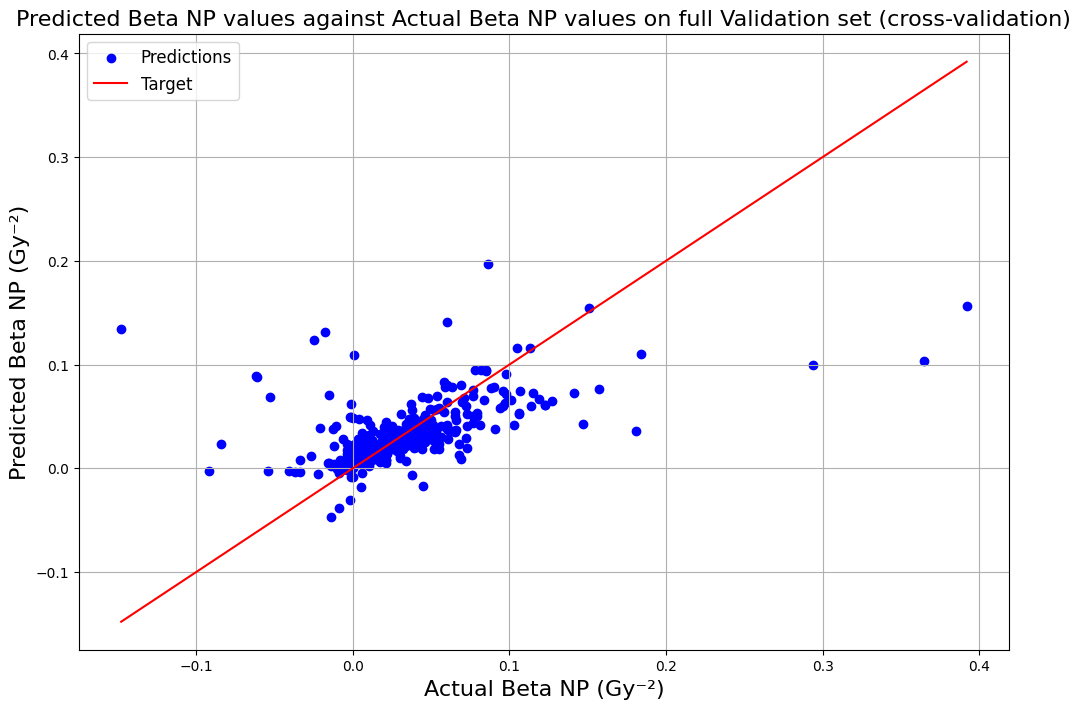

Pearson correlation coefficient:  0.5350058803894788
Pearson p-value:  7.973258191831779e-28
Spearman correlation coefficient:  0.6576134514421598
Spearman p-value:  1.3866262668357308e-45


In [ ]:
#Predictions on full train set for Beta NP

#Import CV predictions
data_cv2 = pd.read_excel("predicted_values_cv2.xlsx")

#Define input and output
x_data_cv2 = data_cv2['Actual Beta NP']
y_data_cv2 = data_cv2['Predicted Beta NP']

#Plot predictions against actual values for Beta NP on full Train subset
plt.figure(figsize=(12,8))
plt.title("Predicted Beta NP values against Actual Beta NP values on full Validation set (cross-validation)", fontsize=16)
plt.scatter(x_data_cv2, y_data_cv2, marker='o', color='blue', label='Predictions')
plt.plot([min(x_data_cv2), max(x_data_cv2)],[min(x_data_cv2), max(x_data_cv2)], color='red', label='Target')
plt.xlabel("Actual Beta NP (Gy\u207B\u00B2)", fontsize=16)
plt.ylabel("Predicted Beta NP (Gy\u207B\u00B2)", fontsize=16)
plt.legend(fontsize='large')
plt.grid(True)
plt.show()

#Print Pearson and Spearman correlation coefficients and p-values
pearson_cv_corr2, pearson_cv_p_value2 = pearsonr(x_data_cv2, y_data_cv2)
print("Pearson correlation coefficient: ", pearson_cv_corr2)
print("Pearson p-value: ", pearson_cv_p_value2)

spearman_cv_corr2, spearman_cv_p_value2 = spearmanr(x_data_cv2, y_data_cv2)
print("Spearman correlation coefficient: ", spearman_cv_corr2)
print("Spearman p-value: ", spearman_cv_p_value2)

**STEP 7 - FULL MODEL TRAINING**

In this section, every final model is trained on the full training subset.

***Single model approach***

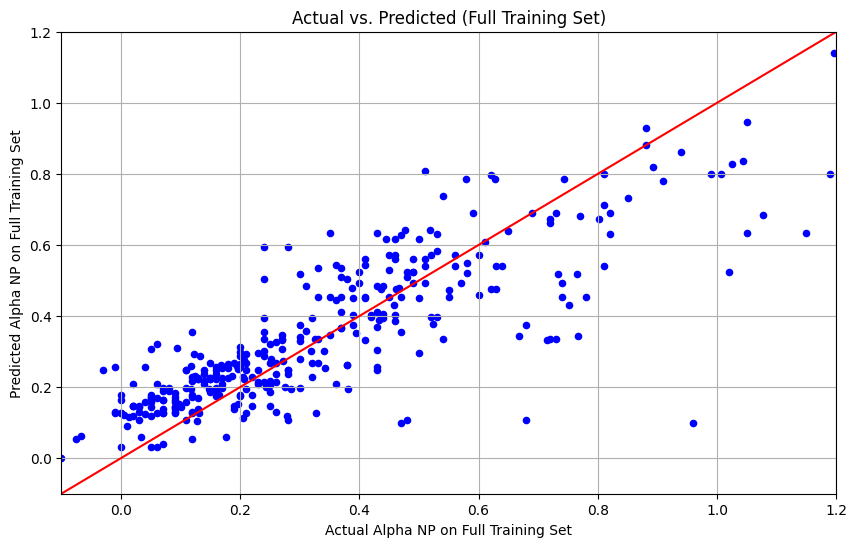

Final Alpha NP Model MSE: 0.024510075635867924


In [ ]:
#Final single model for Alpha NP prediction

scaler_x_final1 = StandardScaler()
scaler_y_final1 = StandardScaler()

x_train_scaled1 = scaler_x_final1.fit_transform(x_train1)
y_train_scaled1 = scaler_y_final1.fit_transform(y_train1.reshape(-1,1)).flatten()

#Fit final single model
final_model1 = best_model1
final_model1.fit(x_train_scaled1, y_train_scaled1)

y_train_pred_scaled_final1 = final_model1.predict(x_train_scaled1)
y_train_pred_final1 = scaler_y_final1.inverse_transform(y_train_pred_scaled_final1.reshape(-1,1)).flatten()

#Plot predictions on the full training set
plt.figure(figsize=(10,6))
plt.scatter(y_train1, y_train_pred_final1, color='blue', s=20)
plt.xlim(-0.1, 1.2)
plt.ylim(-0.1, 1.2)
plt.plot([min(y_train1), max(y_train1)], [min(y_train1), max(y_train1)], color='red')
plt.title("Actual vs. Predicted (Full Training Set)")
plt.xlabel("Actual Alpha NP on Full Training Set")
plt.ylabel("Predicted Alpha NP on Full Training Set")
plt.grid(True)
plt.show()

#Print final metric
final_mse1 = mean_squared_error(y_train1, y_train_pred_final1)
print("Final Alpha NP Model MSE:", final_mse1)

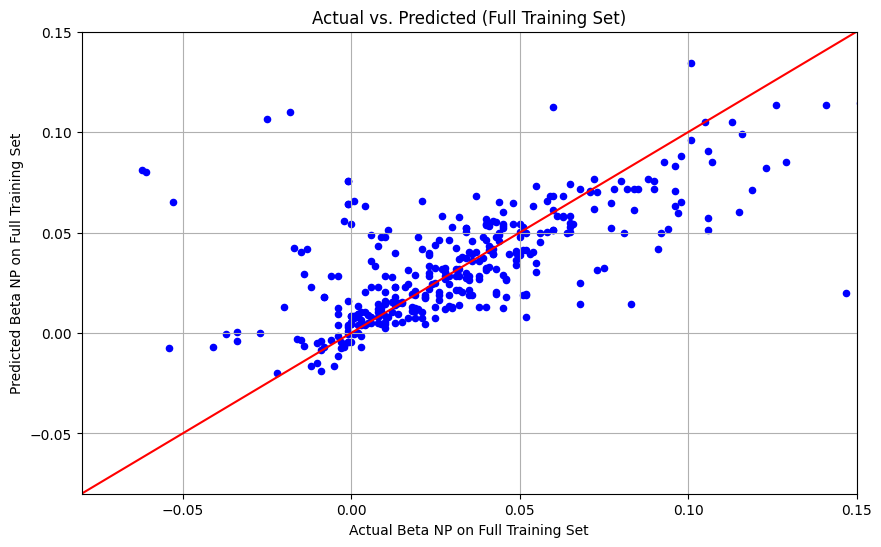

Final Beta NP Model MSE: 0.0013500778665596566


In [ ]:
#Final single model on Beta NP prediction

scaler_x_final2 = StandardScaler()
scaler_y_final2 = StandardScaler()

x_train_scaled2 = scaler_x_final2.fit_transform(x_train2)
y_train_scaled2 = scaler_y_final2.fit_transform(y_train2.reshape(-1,1)).flatten()

#Fit final single model
final_model2 = best_model2
final_model2.fit(x_train_scaled2, y_train_scaled2)

y_train_pred_scaled_final2 = final_model2.predict(x_train_scaled2)
y_train_pred_final2 = scaler_y_final2.inverse_transform(y_train_pred_scaled_final2.reshape(-1,1)).flatten()

#Plot predictions on the full training set
plt.figure(figsize=(10,6))
plt.scatter(y_train2, y_train_pred_final2, color='blue', s=20)
plt.xlim(-0.08, 0.15)
plt.ylim(-0.08, 0.15)
plt.plot([min(y_train2), max(y_train2)], [min(y_train2), max(y_train2)], color='red')
plt.title("Actual vs. Predicted (Full Training Set)")
plt.xlabel("Actual Beta NP on Full Training Set")
plt.ylabel("Predicted Beta NP on Full Training Set")
plt.grid(True)
plt.show()

#Print final metric
final_mse2 = mean_squared_error(y_train2, y_train_pred_final2)
print("Final Beta NP Model MSE:", final_mse2)

***Ensembling approach***

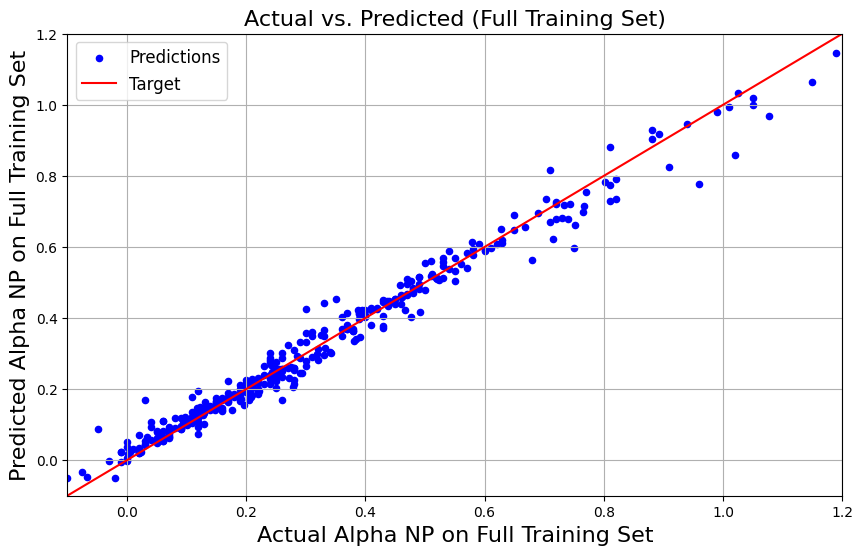

Final Alpha NP Model MSE: 0.0014421416987280176


In [ ]:
#Final ensembling model for Alpha NP prediction

scaler_x_final1 = StandardScaler()
scaler_y_final1 = StandardScaler()

x_train_scaled1 = scaler_x_final1.fit_transform(x_train1)
y_train_scaled1 = scaler_y_final1.fit_transform(y_train1.reshape(-1,1)).flatten()

#Fit final ensembling model
final_model1 = ensemble_model1
final_model1.fit(x_train_scaled1, y_train_scaled1)

y_train_pred_scaled_final1 = final_model1.predict(x_train_scaled1)
y_train_pred_final1 = scaler_y_final1.inverse_transform(y_train_pred_scaled_final1.reshape(-1,1)).flatten()

#Plot predictions on the full training set
plt.figure(figsize=(10,6))
plt.scatter(y_train1, y_train_pred_final1, color='blue', s=20, label='Predictions')
plt.xlim(-0.1, 1.2)
plt.ylim(-0.1, 1.2)
plt.plot([min(y_train1), max(y_train1)], [min(y_train1), max(y_train1)], color='red', label='Target')
plt.title("Actual vs. Predicted (Full Training Set)", fontsize=16)
plt.xlabel("Actual Alpha NP on Full Training Set", fontsize=16)
plt.ylabel("Predicted Alpha NP on Full Training Set", fontsize=16)
plt.grid(True)
plt.legend(fontsize='large')
plt.show()

#Print final metric
final_mse1 = mean_squared_error(y_train1, y_train_pred_final1)
print("Final Alpha NP Model MSE:", final_mse1)

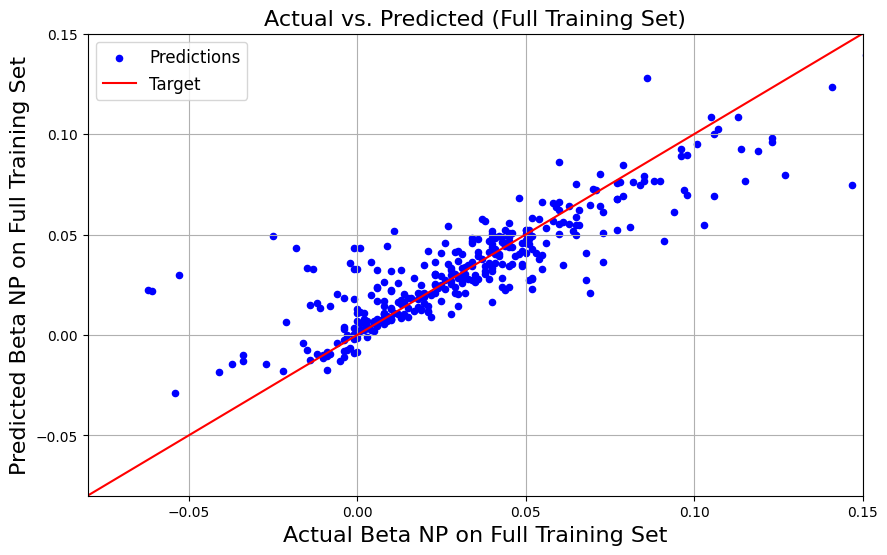

Final Beta NP Model MSE: 0.000603237224320594


In [ ]:
#Final ensembling model on Beta NP prediction

scaler_x_final2 = StandardScaler()
scaler_y_final2 = StandardScaler()

x_train_scaled2 = scaler_x_final2.fit_transform(x_train2)
y_train_scaled2 = scaler_y_final2.fit_transform(y_train2.reshape(-1,1)).flatten()

#Fit final single model
final_model2 = ensemble_model2
final_model2.fit(x_train_scaled2, y_train_scaled2)

y_train_pred_scaled_final2 = final_model2.predict(x_train_scaled2)
y_train_pred_final2 = scaler_y_final2.inverse_transform(y_train_pred_scaled_final2.reshape(-1,1)).flatten()

#Plot predictions on the full training set
plt.figure(figsize=(10,6))
plt.scatter(y_train2, y_train_pred_final2, color='blue', s=20, label='Predictions')
plt.xlim(-0.08, 0.15)
plt.ylim(-0.08, 0.15)
plt.plot([min(y_train2), max(y_train2)], [min(y_train2), max(y_train2)], color='red', label='Target')
plt.title("Actual vs. Predicted (Full Training Set)", fontsize=16)
plt.xlabel("Actual Beta NP on Full Training Set", fontsize=16)
plt.ylabel("Predicted Beta NP on Full Training Set", fontsize=16)
plt.grid(True)
plt.legend(fontsize='large')
plt.show()

#Print final metric
final_mse2 = mean_squared_error(y_train2, y_train_pred_final2)
print("Final Beta NP Model MSE:", final_mse2)

**STEP 8 - PLOT EVALUATION METRICS ON CROSS-VALIDATION RESULTS**

In this section, results on training set cross-validation are computed in order to predict DEF and SER values. Data needs to be imported from an Excel file containing Actual DEF and SER (from the database) and Predicted DEF and SER (calculated from cross-validation predictions of Alpha NP and Beta NP). The DEF predictions have to be cut because of NaN values in the actual database.

In [ ]:
#DEF predictions on full cross-validation

#Import DEF predictions
def_cv = pd.read_excel("def_predictions_cut.xlsx")

x_def_cv = def_cv['DEF actual']
y_def_cv = def_cv['DEF pred']

#Plot DEF CV predictions
plt.figure(figsize=(12,8))
plt.title("DEF predictions on Full Validation set (cross-validation)")
plt.xlabel("Actual DEF values")
plt.ylabel("Predicted DEF values")
plt.scatter(x_def_cv, y_def_cv, marker='o', color='blue', label='Predictions')
plt.plot([min(x_def_cv), max(x_def_cv)], [min(x_def_cv), max(x_def_cv)], color='red', label='Target')
plt.legend()
plt.grid(True)
plt.show()

#Print Pearson and Spearman correlation coefficients and p-values
def_pearson_corr, def_pearson_p_value = pearsonr(x_def_cv, y_def_cv)
print("Pearson correlation coefficient: ", def_pearson_corr)
print("Pearson p-value: ", def_pearson_p_value)

def_spearman_corr, def_spearman_p_value = spearmanr(x_def_cv, y_def_cv)
print("Spearman correlation coefficient: ", def_spearman_corr)
print("Spearman p-value: ", def_spearman_p_value)

FileNotFoundError: [Errno 2] No such file or directory: 'def_predictions_cut.xlsx'

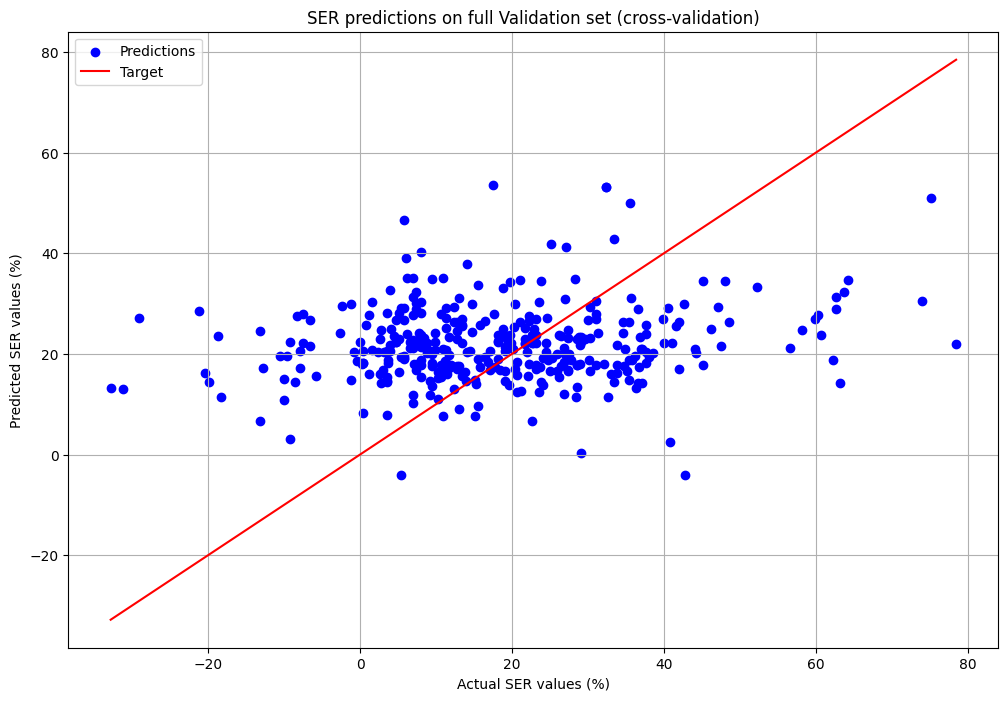

Pearson correlation coefficient:  0.1766863302972341
Pearson p-value:  0.0007991187174847139
Spearman correlation coefficient:  0.11499917514364852
Spearman p-value:  0.02982269754139209


In [ ]:
#SER predictions on full cross-validation

#Import SER predictions
ser_cv = pd.read_excel("ser_predictions.xlsx")

x_ser_cv = ser_cv['SER actual']
y_ser_cv = ser_cv['SER pred']

#Plot SER CV predictions
plt.figure(figsize=(12,8))
plt.title("SER predictions on full Validation set (cross-validation)")
plt.xlabel("Actual SER values (%)")
plt.ylabel("Predicted SER values (%)")
plt.scatter(x_ser_cv, y_ser_cv, marker='o', color='blue', label='Predictions')
plt.plot([min(x_ser_cv), max(x_ser_cv)], [min(x_ser_cv), max(x_ser_cv)], color='red', label='Target')
plt.legend()
plt.grid(True)
plt.show()

#Print Pearson and Spearman correlation coefficients and p-values
ser_pearson_corr, ser_pearson_p_value = pearsonr(x_ser_cv, y_ser_cv)
print("Pearson correlation coefficient: ", ser_pearson_corr)
print("Pearson p-value: ", ser_pearson_p_value)

ser_spearman_corr, ser_spearman_p_value = spearmanr(x_ser_cv, y_ser_cv)
print("Spearman correlation coefficient: ", ser_spearman_corr)
print("Spearman p-value: ", ser_spearman_p_value)

**STEP 9 - EVALUATE THE MODELS ON TEST SET**

In this section, we use the test set to evaluate the model on unseen data.

In [ ]:
#Evaluation of the Alpha NP Predictor model
y_train_pred_scaled_final1 = final_model1.predict(x_train_scaled1)
y_train_pred_final1 = scaler_y_final1.inverse_transform(y_train_pred_scaled_final1.reshape(-1,1)).flatten()

train_mse_final1 = mean_squared_error(y_train1, y_train_pred_final1)

x_test_scaled1 = scaler_x_final1.fit_transform(x_test1)

y_test_pred_scaled_final1 = final_model1.predict(x_test_scaled1)
y_test_pred_final1 = scaler_y_final1.inverse_transform(y_test_pred_scaled_final1.reshape(-1,1)).flatten()

test_mse_final1 = mean_squared_error(y_test1, y_test_pred_final1)

test_predictions1 = y_test_pred_final1

#Compare metrics of training set and test set
print("MSE for Alpha NP Full Training Set:", train_mse_final1)
print("MSE for Alpha NP Test Set:", test_mse_final1)

MSE for Alpha NP Full Training Set: 0.02324277320502321
MSE for Alpha NP Test Set: 0.02533153202246606


In [ ]:
#Evaluation of the Beta NP Predictor model
y_train_pred_scaled_final2 = final_model2.predict(x_train_scaled2)
y_train_pred_final2 = scaler_y_final2.inverse_transform(y_train_pred_scaled_final2.reshape(-1,1)).flatten()

train_mse_final2 = mean_squared_error(y_train2, y_train_pred_final2)

x_test_scaled2 = scaler_x_final2.fit_transform(x_test2)

y_test_pred_scaled_final2 = final_model2.predict(x_test_scaled2)
y_test_pred_final2 = scaler_y_final2.inverse_transform(y_test_pred_scaled_final2.reshape(-1,1)).flatten()

test_mse_final2 = mean_squared_error(y_test2, y_test_pred_final2)

test_predictions2 = y_test_pred_final2

#Compare metrics of training set and test set
print("MSE for Beta NP Full Training Set:", train_mse_final2)
print("MSE for Beta NP Test Set:", test_mse_final2)

MSE for Beta NP Full Training Set: 0.0014583483312496353
MSE for Beta NP Test Set: 0.0011083874119252144


**STEP 10 - MAKE PREDICTIONS ON TEST SET**

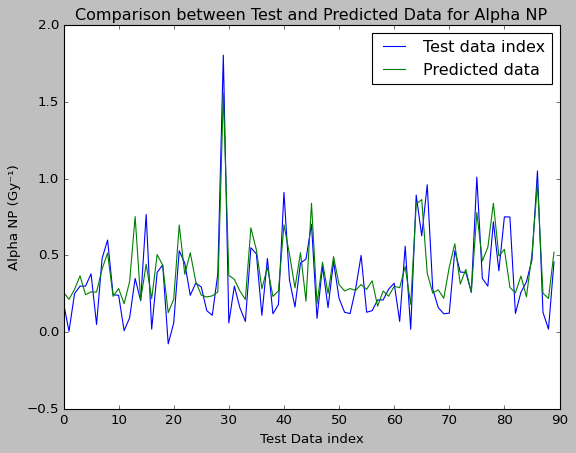

In [ ]:
#Plot predictions against test index for Alpha NP Predictor
num_outputs1 = len(y_test1)
test_predictions1 = y_test_pred_final1

plt.figure()
plt.plot(y_test1, label='Test data index')
plt.plot(test_predictions1, label='Predicted data')
plt.xlabel('Test Data index')
plt.ylabel(f'Alpha NP (Gy\u207B\u00B9)')
plt.title(f'Comparison between Test and Predicted Data for Alpha NP')
plt.legend()
plt.show()

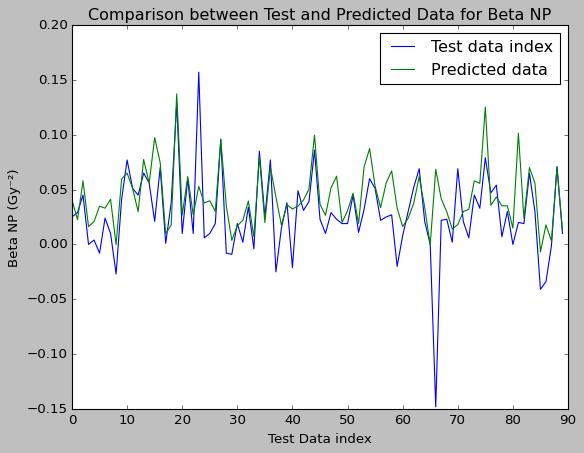

In [ ]:
#Plot predictions against test index for Beta NP Predictor
num_outputs2 = len(y_test2)
test_predictions2 = y_test_pred_final2

plt.figure()
plt.plot(y_test2, label='Test data index')
plt.plot(test_predictions2, label='Predicted data')
plt.xlabel('Test Data index')
plt.ylabel(f'Beta NP (Gy\u207B\u00B2)')
plt.title(f'Comparison between Test and Predicted Data for Beta NP')
plt.legend()
plt.show()

In [ ]:
#Prediction evaluation on test set for Alpha NP Predictor
print('Index       Predicted alpha      Real alpha          Error         Relative Error (%)')

for i in range (len(y_test1)):
  index1 = 1*[i]
  pred1 = test_predictions1[i]
  real1 = y_test1[:,0][i]
  error1 = pred1 - real1
  abs_error1 = abs(error1)
  relative_error1 = abs(100 * (abs_error1 / real1))

  print(f"{index1}", f"{pred1:.2f}", f"{real1:.2f}", f"{error1:.3f}", f"{relative_error1:.2f}", sep='              ')

Index       Predicted alpha      Real alpha          Error         Relative Error (%)
[0]              0.26              0.19              0.069              36.53
[1]              0.21              0.01              0.208              3474.38
[2]              0.28              0.25              0.027              10.84
[3]              0.37              0.30              0.066              22.11
[4]              0.24              0.30              -0.055              18.43
[5]              0.26              0.38              -0.118              31.11
[6]              0.26              0.05              0.212              423.67
[7]              0.41              0.48              -0.069              14.28
[8]              0.52              0.60              -0.085              14.11
[9]              0.23              0.24              -0.011              4.46
[10]              0.28              0.24              0.044              18.45
[11]              0.19              0.01        

In [ ]:
#Prediction evaluation on test set for Beta NP Predictor
print('Index       Predicted beta      Real beta          Error         Relative Error (%)')

for i in range (len(y_test2)):
  index2 = 1*[i]
  pred2 = test_predictions2[i]
  real2 = y_test2[:,0][i]
  error2 = pred2 - real2
  abs_error2 = abs(error2)
  relative_error2 = abs(100 * (abs_error2 / real2))

  print(f"{index2}", f"{pred2:.3f}", f"{real2:.3f}", f"{error2:.3f}", f"{relative_error2:.2f}", sep='              ')

Index       Predicted beta      Real beta          Error         Relative Error (%)
[0]              0.040              0.025              0.015              61.13
[1]              0.023              0.029              -0.006              22.00
[2]              0.058              0.045              0.013              28.98
[3]              0.016              0.000              0.016              inf
[4]              0.021              0.004              0.017              421.93
[5]              0.035              -0.008              0.043              535.91
[6]              0.033              0.024              0.009              37.63
[7]              0.041              0.010              0.031              310.87
[8]              -0.000              -0.027              0.027              99.15
[9]              0.060              0.041              0.019              45.30
[10]              0.065              0.077              -0.012              15.50
[11]              0.051      

<ipython-input-213-2407970e7cad>:10: RuntimeWarning: divide by zero encountered in scalar divide
  relative_error2 = abs(100 * (abs_error2 / real2))


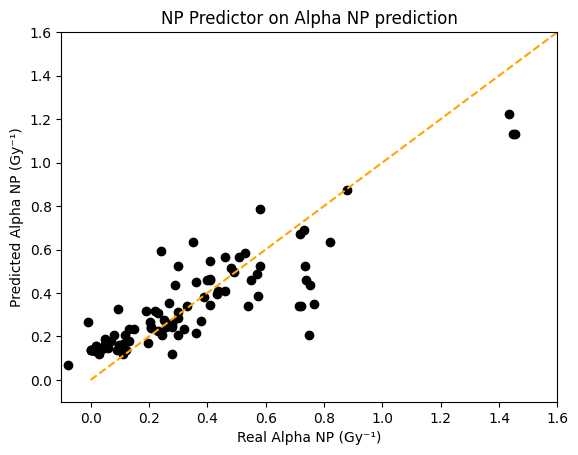

Pearson correlation coefficient:  0.8657264922745482
Pearson p-value:  3.454390336861147e-28
Spearman correlation coefficient:  0.8352421965546137
Spearman p-value:  1.4070765393141202e-24


In [ ]:
#Plot calibration curve on test set for Alpha NP Predictor
x_values1 = np.linspace(0,1.6,100)
y_values1 = x_values1

#Correlation between predictions and test on Alpha NP value
plt.scatter(y_test1,test_predictions1,marker='o',color="black")
plt.plot(x_values1, y_values1, linestyle='--', color='orange')
plt.xlim(-0.1, 1.6)
plt.ylim(-0.1, 1.6)
plt.xlabel("Real Alpha NP (Gy\u207B\u00B9)")
plt.ylabel("Predicted Alpha NP (Gy\u207B\u00B9)")
plt.title("NP Predictor on Alpha NP prediction")
plt.show()

#Print Pearson and Spearman correlation coefficients and p-values
pearson_corr, pearson_p_value = pearsonr(y_test1[:,0],test_predictions1)
print("Pearson correlation coefficient: ", pearson_corr)
print("Pearson p-value: ", pearson_p_value)

spearman_corr, spearman_p_value = spearmanr(y_test1[:,0],test_predictions1)
print("Spearman correlation coefficient: ", spearman_corr)
print("Spearman p-value: ", spearman_p_value)

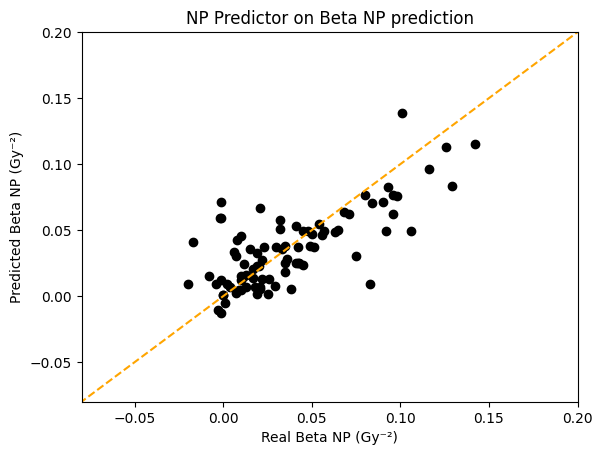

Pearson correlation coefficient:  0.6584172468011439
Pearson p-value:  1.7547518414741887e-12
Spearman correlation coefficient:  0.6549842026363972
Spearman p-value:  2.4996129664177517e-12


In [ ]:
#Plot calibration curve on test set for Beta NP Predictor
x_values2 = np.linspace(-0.15,0.25,100)
y_values2 = x_values2

#Correlation between predictions and test on Beta NP value
plt.scatter(y_test2,test_predictions2,marker='o',color="black")
plt.plot(x_values2, y_values2, linestyle='--', color='orange')
plt.xlabel("Real Beta NP (Gy\u207B\u00B2)")
plt.ylabel("Predicted Beta NP (Gy\u207B\u00B2)")
plt.xlim(-0.08,0.2)
plt.ylim(-0.08,0.2)
plt.title("NP Predictor on Beta NP prediction")
plt.show()

#Print Pearson and Spearman correlation coefficients and p-values
pearson_corr, pearson_p_value = pearsonr(y_test2[:,0],test_predictions2)
print("Pearson correlation coefficient: ", pearson_corr)
print("Pearson p-value: ", pearson_p_value)

spearman_corr, spearman_p_value = spearmanr(y_test2[:,0],test_predictions2)
print("Spearman correlation coefficient: ", spearman_corr)
print("Spearman p-value: ", spearman_p_value)

**STEP 11 - USER INTERFACE: CREATE NEW EXPERIMENTAL SCENARIOS**

In this section, the user is allowed to manually type input parameters in order to get an output prediction for a defined irradiation experiment.

In [ ]:
#Input dialog boxes
def get_input_features():
  features = []
  print("Please enter the values for the input features:")
  for name in feature_names_inbox:
    feature_value = float(input(f"{name}: "))
    features.append(feature_value)
  return features

#List of input features
feature_names_inbox = [
    "Atomic number Z of the metallic nanoparticle",
    "Core diameter of the nanoparticle (nm)",
    "Nanoparticle solution concentration (mmol/L)",
    "Incubation time (h)",
    "Cell line category (Non-cancerous = 0 ; Very radioresistant = 1 ; Radioresistant = 2 ; Mildly radiosensistive = 3 ; Radiosensitive = 4 ; Very radiosensitive = 5)",
    "Oxygenation conditions (Normoxic = 2 ; Hypoxic = 1 ; Anoxic = 0)",
    "Nature of ionizing ray (X-ray = 1 ; Gamma-ray = 2 ; Electron = 3 ; Proton = 4 ; Helium ion = 5 ; Carbon ion = 6)",
    "Energy of ionizing ray (keV)",
    "Linear Energy Transfer (keV/um)",
    "Alpha Control (Gy-1)",
    "Beta Control (Gy-2)"
    ]

input_features = get_input_features()
print("Input features:", input_features)

Please enter the values for the input features:
Atomic number Z of the metallic nanoparticle: 79
Core diameter of the nanoparticle (nm): 12
Nanoparticle solution concentration (mmol/L): 1
Incubation time (h): 24
Cell line category (Non-cancerous = 0 ; Very radioresistant = 1 ; Radioresistant = 2 ; Mildly radiosensistive = 3 ; Radiosensitive = 4 ; Very radiosensitive = 5): 1
Oxygenation conditions (Normoxic = 2 ; Hypoxic = 1 ; Anoxic = 0): 2
Nature of ionizing ray (X-ray = 1 ; Gamma-ray = 2 ; Electron = 3 ; Proton = 4 ; Helium ion = 5 ; Carbon ion = 6): 1
Energy of ionizing ray (keV): 50
Linear Energy Transfer (keV/um): 0
Alpha Control (Gy-1): 0.22
Beta Control (Gy-2): 0.019
Input features: [79.0, 12.0, 1.0, 24.0, 1.0, 2.0, 1.0, 50.0, 0.0, 0.22, 0.019]


In [ ]:
#Whole set data recuperation and standardization
mean = x_data.mean()
std = x_data.std()
x_data_standardized = (x_data - mean) / std

#Convert y_data into a Numpy array
y_data1 = np.ravel(y_data1)
y_data2 = np.ravel(y_data2)

display(x_data.describe().style.format("{0:.2f}").set_caption("x_data"))
display(x_data_standardized.describe().style.format("{0:.2f}").set_caption("x_data_standardized"))

#Standardization of user inputs
means = np.mean(x_data, axis=0)
stds = np.std(x_data, axis=0)

manually_standardized_input_features = [(x - mean) / std for x, mean, std in zip (input_features, means, stds)]
print("List of manually standardized input features:")
print(manually_standardized_input_features)

#Fit models on whole dataset
regression_model1 = final_model1.fit(x_data_standardized, y_data1)
regression_model2 = final_model2.fit(x_data_standardized, y_data2)

,Np_type,Diam,Concentration,Incubation,Cell_type,Oxygenation,Ray_type,Energy,Let,Alpha_ctrl,Beta_ctrl
count,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00
mean,66.53,28.53,3.69,19.93,2.42,1.92,1.82,274877.93,4.87,0.23,0.04
std,19.84,43.28,15.26,20.08,1.23,0.33,1.58,854814.06,16.16,0.24,0.03
min,22.00,1.20,0.00,0.00,0.00,0.00,1.00,6.50,0.00,-0.32,-0.02
25%,64.00,3.00,0.10,6.00,2.00,2.00,1.00,67.00,0.00,0.06,0.01
50%,78.00,12.70,0.50,24.00,2.00,2.00,1.00,380.00,0.00,0.15,0.03
75%,79.00,50.00,0.80,24.00,3.00,2.00,2.00,2000.00,0.00,0.36,0.05
max,83.00,496.00,100.00,168.00,5.00,2.00,6.00,3480000.00,110.00,1.54,0.20


,Np_type,Diam,Concentration,Incubation,Cell_type,Oxygenation,Ray_type,Energy,Let,Alpha_ctrl,Beta_ctrl
count,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00
mean,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.24,-0.63,-0.24,-0.99,-1.97,-5.78,-0.52,-0.32,-0.30,-2.28,-1.82
25%,-0.13,-0.59,-0.24,-0.69,-0.34,0.23,-0.52,-0.32,-0.30,-0.70,-0.79
50%,0.58,-0.37,-0.21,0.20,-0.34,0.23,-0.52,-0.32,-0.30,-0.32,-0.13
75%,0.63,0.50,-0.19,0.20,0.47,0.23,0.11,-0.32,-0.30,0.55,0.50
max,0.83,10.80,6.31,7.37,2.10,0.23,2.64,3.75,6.51,5.44,5.32


List of manually standardized input features:
[0.6292292746874624, -0.38238175368170113, -0.17623874323342975, 0.20298895871587788, -1.1594917759872694, 0.2287708681301762, -0.5203213349436375, -0.3218663199669124, -0.3016108482100199, -0.03404877569286387, -0.5957203219296754]


In [ ]:
#Make a prediction
predicted_alpha = regression_model1.predict([manually_standardized_input_features])
predicted_beta = regression_model2.predict([manually_standardized_input_features])

#Inputs recuperation (Alpha Control and Beta Control)
Alpha_input = input_features[9]
Beta_input = input_features[10]

print("Alpha Control =", Alpha_input, "Gy-1")
print("Beta Control =", Beta_input, "Gy-2")

#Outputs recuperation (Alpha NP and Beta NP)
Alpha_output = predicted_alpha[0]
Beta_output = predicted_beta[0]

print("Predicted Alpha NP =", "{:.2f}".format(Alpha_output), "Gy-1")
print("Predicted Beta NP =", "{:.3f}".format(Beta_output), "Gy-2")


#Extrapolated output quantities
Sref = 0.1
Dref = 2  #[Gy]

print("Alpha Control =", "{:.2f}".format(Alpha_input), "Gy-1")
print("Beta Control =", "{:.3f}".format(Beta_input), "Gy-2")
print("Alpha NP =", "{:.2f}".format(Alpha_output), "Gy-1")
print("Beta NP =", "{:.3f}".format(Beta_output), "Gy-2")

#SF Control at Dref
def Sctrl(Alpha_input, Beta_input, Dref):
  return np.exp(-Alpha_input * Dref - Beta_input * Dref**2)
Sctrl = Sctrl(Alpha_input, Beta_input, Dref)
print("Sctrl =","{:.3f}".format(Sctrl))

#SF NP at Dref
def Snp(Alpha_output, Beta_output, Dref):
  return np.exp(-Alpha_output * Dref - Beta_output * Dref**2)
Snp = Snp(Alpha_output, Beta_output, Dref)
print("Snp =","{:.3f}".format(Snp))

#Delta Control for SFref
def Delta_ctrl(Alpha_input, Beta_input, Sref):
  return (Alpha_input**2 - 4 * Beta_input * np.log(Sref))
Delta_ctrl = Delta_ctrl(Alpha_input, Beta_input, Sref)
print("Delta_ctrl =","{:.3f}".format(Delta_ctrl), "Gy-2")

#Delta NP for SFref
def Delta_np(Alpha_output, Beta_output, Sref):
  return (Alpha_output**2 - 4 * Beta_output * np.log(Sref))
Delta_np = Delta_np(Alpha_output, Beta_output, Sref)
print("Delta_np =","{:.3f}".format(Delta_np), "Gy-2")

#Control dose for SFref
def Dctrl(Alpha_input, Beta_input, Sref):
  return ((-Alpha_input + np.sqrt(Delta_ctrl))/(2 * Beta_input))
Dctrl = Dctrl(Alpha_input, Beta_input, Sref)
print("Dctrl =","{:.2f}".format(Dctrl), "Gy")

#NP dose for SFref
def Dnp(Alpha_output, Beta_output, Sref):
  return((-Alpha_output + np.sqrt(Delta_np))/(2 * Beta_output))
Dnp = Dnp(Alpha_output, Beta_output, Sref)
print("Dnp =","{:.2f}".format(Dnp), "Gy")

#Dose Enhancement Factor for SFref
def DEF(Dctrl,Dnp):
  return Dctrl / Dnp
DEF = DEF(Dctrl,Dnp)
print("DEF =","{:.3f}".format(DEF))

#Sensitizing Enhancement Ratio for Dref
def SER(Sctrl,Snp):
  return 100 * ((Sctrl - Snp) / Sctrl)
SER = SER(Sctrl,Snp)
print("SER =","{:.2f}".format(SER), "%")


#LQ Model plotting preparation
a1 = Alpha_input
b1 = Beta_input
a2 = Alpha_output
b2 = Beta_output
D = np.linspace(0, 8, 1000)
SF1 = np.exp(-a1*D - b1*D**2)
SF2 = np.exp(-a2*D - b2*D**2)

Alpha Control = 0.22 Gy-1
Beta Control = 0.019 Gy-2
Predicted Alpha NP = 0.38 Gy-1
Predicted Beta NP = -0.014 Gy-2
Alpha Control = 0.22 Gy-1
Beta Control = 0.019 Gy-2
Alpha NP = 0.38 Gy-1
Beta NP = -0.014 Gy-2
Sctrl = 0.597
Snp = 0.496
Delta_ctrl = 0.223 Gy-2
Delta_np = 0.013 Gy-2
Dctrl = 6.65 Gy
Dnp = 9.31 Gy
DEF = 0.714
SER = 16.94 %


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


In [ ]:
#Display results of the predictions
final_data = [Alpha_input, Beta_input, Alpha_output, Beta_output, Sctrl, Snp, Dctrl, Dnp, DEF, SER]
final_labels = ['Alpha Control (Gy-1)', 'Beta Control (Gy-2)', 'Alpha NP (Gy-1)', 'Beta NP (Gy-2)', 'SF Control', 'SF NP', 'D Control (Gy)', 'D NP (Gy)', 'DEF', 'SER (%)']
decimal_places = [2, 3, 2, 3, 3, 3, 2, 2, 2, 2]

formatted_data = [f"{value:.{dp}f}" for value, dp in zip(final_data, decimal_places)]

df = pd.DataFrame({'Quantity': final_labels, 'Value': formatted_data})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df_styled = df.style.set_properties(**{'text-align': 'center'})
df_styled = df_styled.applymap(lambda x: 'font-size: 14px')
df_styled

,Quantity,Value
0,Alpha Control (Gy-1),0.22
1,Beta Control (Gy-2),0.019
2,Alpha NP (Gy-1),0.38
3,Beta NP (Gy-2),-0.014
4,SF Control,0.597
5,SF NP,0.496
6,D Control (Gy),6.65
7,D NP (Gy),9.31
8,DEF,0.71
9,SER (%),16.94


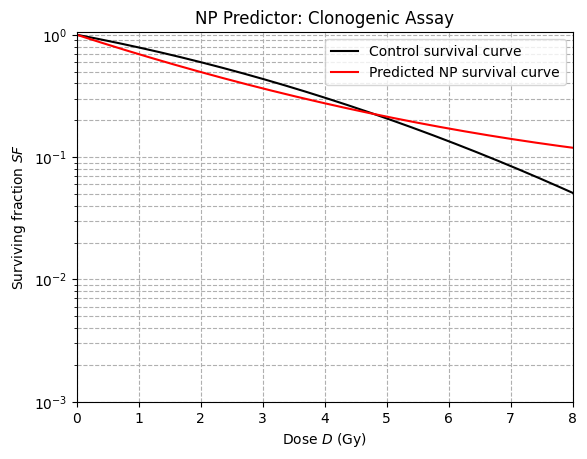

In [ ]:
#Plot model prediction curves
plt.plot(D, SF1, linestyle='-', color='black', label='Control survival curve')
plt.plot(D, SF2, linestyle='-', color='r', label='Predicted NP survival curve')
plt.grid(True, which="both", linestyle='--')

plt.gca().set_xlim(0, 8)
plt.gca().set_ylim(10**(-3), 1.05)
plt.yscale('log')
plt.title("NP Predictor: Clonogenic Assay")
plt.xlabel("Dose $D$ (Gy)")
plt.ylabel("Surviving fraction $SF$")
plt.legend(loc="upper right")
plt.style.use('classic')
plt.show()